# 1. Project Title and Research Problem

# Big Data Anti-Money Laundering Detection Using Graph-Based Feature Engineering, Imbalanced Learning, and Explainable Machine Learning

**Course:** Artificial Intelligence and Big Data

**Case:** Financial fraud and suspicious transaction detection.

**Dataset:** SAML-D Anti Money Laundering Transaction Data from Kaggle dataset `berkanoztas/synthetic-transaction-monitoring-dataset-aml`.

**Research problem:** Suspicious AML transactions are rare and hidden inside large-scale normal transaction data. This project uses PySpark, graph-based feature engineering, imbalanced learning, and machine learning to detect suspicious transactions from transaction-monitoring records.

The requested target concept is suspicious AML behavior. In this actual SAML-D CSV, the target column is `Is_laundering`, which is normalized into the binary `label` column. The workflow is designed so the full dataset is processed with PySpark and is never converted fully to Pandas.

## Project Summary

| Item | Description |
| --- | --- |
| Project title | Big Data Anti-Money Laundering Detection Using Graph-Based Feature Engineering, Imbalanced Learning, and Explainable Machine Learning |
| Case study | Financial fraud / AML suspicious transaction detection |
| Dataset name | SAML-D Anti Money Laundering Transaction Data |
| Big Data tool | PySpark |
| Main target | `Is_laundering` in the provided CSV, representing suspicious AML behavior requested as `Is Suspicious` |
| Main models | Logistic Regression and LightGBM |
| Main metrics | Recall, F1-score, ROC-AUC, PR-AUC |

This notebook is designed as the main project report. Important tables, figures, interpretations, model comparisons, and conclusions are displayed directly inside the notebook. Exported files in `outputs/` are backup artifacts.

## Big Data Justification

The SAML-D dataset can contain about 9.5 million transaction rows. Loading that full table into Pandas can exceed laptop memory and does not represent a Big Data workflow. PySpark is therefore used for CSV loading, schema inspection, exploratory aggregation, preprocessing, feature engineering, graph-style sender-receiver aggregations, and Parquet persistence.

Pandas is used only for small aggregated outputs and the controlled training sample used by scikit-learn and LightGBM.

## Actual SAML-D CSV Profile

The actual dataset file provided is `SAML-D.csv`. Its columns are:

`Time`, `Date`, `Sender_account`, `Receiver_account`, `Amount`, `Payment_currency`, `Received_currency`, `Sender_bank_location`, `Receiver_bank_location`, `Payment_type`, `Is_laundering`, `Laundering_type`.

A streaming scan found 9,504,852 rows. The target column is `Is_laundering`: 9,494,979 normal transactions (`0`) and 9,873 laundering transactions (`1`), giving a laundering ratio of about 0.104%. This confirms the project is a highly imbalanced AML detection problem.

`Laundering_type` is treated as a typology/analysis column and excluded from model training to avoid leakage. `Date` and `Time` are combined for transaction time features.


## 2. Library Import and Configuration

In [30]:
from pathlib import Path
import os
import sys
import json
import warnings
import logging
import re

import pandas as pd
import numpy as np
import matplotlib
# Use the notebook inline backend when available; figures are also saved to disk.
import matplotlib.pyplot as plt

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, StringType, TimestampType
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import StringIndexer

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

import lightgbm
from lightgbm import LGBMClassifier
import joblib
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Windows-friendly relative project-root detection.
CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

DATA_RAW_DIR = ROOT_DIR / "data" / "raw"
DATA_PROCESSED_DIR = ROOT_DIR / "data" / "processed"
DATA_SAMPLE_DIR = ROOT_DIR / "data" / "sample"
FIGURES_DIR = ROOT_DIR / "outputs" / "figures"
METRICS_DIR = ROOT_DIR / "outputs" / "metrics"
MODELS_DIR = ROOT_DIR / "outputs" / "models"
REPORTS_DIR = ROOT_DIR / "outputs" / "reports"
LOGS_DIR = ROOT_DIR / "outputs" / "logs"

for folder in [
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    DATA_SAMPLE_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    LOGS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(LOGS_DIR / "notebook_pipeline.log", encoding="utf-8"),
        logging.StreamHandler(),
    ],
)
logger = logging.getLogger("aml_bigdata_notebook")

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Windows Spark/Hadoop local filesystem fix.
# Spark uses Hadoop's local filesystem layer when writing Parquet. On Windows,
# Hadoop expects HADOOP_HOME/bin/winutils.exe to exist before SparkSession starts.
HADOOP_HOME_DIR = ROOT_DIR / ".local" / "hadoop"
HADOOP_BIN_DIR = HADOOP_HOME_DIR / "bin"
HADOOP_BIN_DIR.mkdir(parents=True, exist_ok=True)

if os.name == "nt":
    winutils_path = HADOOP_BIN_DIR / "winutils.exe"
    hadoop_dll_path = HADOOP_BIN_DIR / "hadoop.dll"
    os.environ["HADOOP_HOME"] = str(HADOOP_HOME_DIR)
    os.environ["hadoop.home.dir"] = str(HADOOP_HOME_DIR)
    os.environ["PATH"] = str(HADOOP_BIN_DIR) + os.pathsep + os.environ.get("PATH", "")
    if not winutils_path.exists():
        print(f"Missing {winutils_path}. Download winutils.exe into this folder before writing Spark Parquet on Windows.")
    if not hadoop_dll_path.exists():
        print(f"Missing {hadoop_dll_path}. Download hadoop.dll into this folder if Spark raises a NativeIO error on Windows.")

print(f"Project root: {ROOT_DIR}")
print(f"PySpark version: {pyspark.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"LightGBM version: {lightgbm.__version__}")

Project root: d:\Telkom University Kuliah\Kuliah S1\Tugas S1\Semester 6\Big Data dan AI\Final Project\aml_bigdata_project
PySpark version: 4.1.1
scikit-learn version: 1.6.1
LightGBM version: 4.6.0


## 2A. Self-contained Python Source Functions

This section embeds the reusable Python logic directly into the notebook. The old external `.py` helper files have been removed, so the final-project analysis can be reviewed from this notebook alone.


In [31]:
# Self-contained reusable functions for the notebook workflow.
# Old external .py helper files have been removed; the notebook contains the logic needed for analysis.
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Tuple
try:
    import yaml
except ImportError:
    yaml = None


# ---- Utility functions ----
"""Shared utilities for logging and small artifact writes."""

import json
import logging
from pathlib import Path
from typing import Any, Dict

import pandas as pd


def configure_logging(log_dir: Path) -> None:
    """Configure console and file logging."""
    log_dir.mkdir(parents=True, exist_ok=True)
    log_file = log_dir / "pipeline.log"
    handlers = [
        logging.StreamHandler(),
        logging.FileHandler(log_file, encoding="utf-8"),
    ]
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        handlers=handlers,
        force=True,
    )


def get_logger(name: str) -> logging.Logger:
    """Return a module logger."""
    return logging.getLogger(name)


def save_json(data: Dict[str, Any], path: Path) -> None:
    """Save a JSON artifact."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, indent=2, default=str)


def load_json(path: Path) -> Dict[str, Any]:
    """Load a JSON artifact."""
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def save_pandas_csv(df: pd.DataFrame, path: Path) -> None:
    """Save a small pandas dataframe to CSV."""
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def ensure_parent(path: Path) -> None:
    """Create the parent directory for a file path."""
    path.parent.mkdir(parents=True, exist_ok=True)

# ---- Column schema utility functions ----
"""Column-name utilities for datasets with inconsistent naming conventions."""

import re
from typing import Iterable, List, Optional


def normalize_column_name(name: str) -> str:
    """Normalize a column name for flexible matching."""
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def build_column_lookup(df) -> dict:
    """Build a normalized-name lookup for a Spark dataframe."""
    return {normalize_column_name(column): column for column in df.columns}


def find_column(
    df,
    candidates: Iterable[str],
    required: bool = False,
    semantic_name: str = "",
) -> Optional[str]:
    """Find the first dataframe column matching any candidate name."""
    lookup = build_column_lookup(df)
    for candidate in candidates:
        matched = lookup.get(normalize_column_name(candidate))
        if matched:
            return matched
    if required:
        label = semantic_name or ", ".join(candidates)
        available = ", ".join(df.columns)
        raise ValueError(f"Required column not found for {label}. Available columns: {available}")
    return None


def safe_select_existing(df, columns: Iterable[str]) :
    """Select only columns that exist in the dataframe."""
    existing: List[str] = [column for column in columns if column in df.columns]
    return df.select(*existing)

# ---- Settings functions ----
"""Project configuration loading and path management."""

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict

import yaml



@dataclass
class Settings:
    """Container for project configuration and resolved paths."""

    root_dir: Path
    config_path: Path
    config: Dict[str, Any]
    paths: Dict[str, Path]

    def get(self, *keys, default=None):
        """Read a nested config value."""
        current: Any = self.config
        for key in keys:
            if not isinstance(current, dict) or key not in current:
                return default
            current = current[key]
        return current


def load_settings(config_path: str = "config/config.yaml") -> Settings:
    """Load YAML settings, resolve paths, and create output directories."""
    root_dir = ROOT_DIR
    resolved_config = (root_dir / config_path).resolve()
    if not resolved_config.exists():
        raise FileNotFoundError(
            f"Configuration file is missing: {resolved_config}. "
            "Create config/config.yaml before running the pipeline."
        )

    with resolved_config.open("r", encoding="utf-8") as file:
        config = yaml.safe_load(file) or {}

    configured_paths = config.get("paths", {})
    paths = {name: (root_dir / value).resolve() for name, value in configured_paths.items()}
    for path in paths.values():
        path.mkdir(parents=True, exist_ok=True)

    configure_logging(paths["logs_dir"])
    return Settings(root_dir=root_dir, config_path=resolved_config, config=config, paths=paths)

# ---- Spark session functions ----
"""Spark session factory."""

from pyspark.sql import SparkSession


def create_spark_session(settings) -> SparkSession:
    """Create and configure a SparkSession from project settings."""
    spark_config = settings.config.get("spark", {})
    spark = (
        SparkSession.builder.appName(spark_config.get("app_name", "AML Big Data"))
        .master(spark_config.get("master", "local[*]"))
        .config("spark.driver.memory", spark_config.get("driver_memory", "8g"))
        .config("spark.executor.memory", spark_config.get("executor_memory", "8g"))
        .config("spark.sql.shuffle.partitions", str(spark_config.get("shuffle_partitions", 64)))
        .config("spark.default.parallelism", str(spark_config.get("default_parallelism", 64)))
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
    return spark

# ---- Data loading functions ----
"""Raw SAML-D dataset discovery and loading."""

from pathlib import Path
from typing import Optional


LOGGER = get_logger(__name__)


def find_raw_csv(settings) -> Optional[Path]:
    """Find a raw CSV file under data/raw using configured filename candidates first."""
    raw_dir = settings.paths["raw_data_dir"]
    candidates = settings.get("data", "raw_filename_candidates", default=[])
    for filename in candidates:
        candidate = raw_dir / filename
        if candidate.exists():
            return candidate

    csv_files = sorted(raw_dir.glob("*.csv"))
    return csv_files[0] if csv_files else None


def load_raw_data(spark, settings):
    """Load the raw CSV into Spark and save a schema summary."""
    raw_path = find_raw_csv(settings)
    if raw_path is None:
        message = "Please download the Kaggle dataset and place the CSV file in data/raw/"
        LOGGER.error(message)
        raise FileNotFoundError(message)

    try:
        LOGGER.info("Loading raw CSV from %s", raw_path)
        df = (
            spark.read.option("header", True)
            .option("inferSchema", True)
            .option("multiLine", False)
            .option("escape", '"')
            .csv(str(raw_path))
        )
        LOGGER.info("Raw schema:")
        df.printSchema()
        row_count = df.count()
        LOGGER.info("Loaded %s rows and %s columns", row_count, len(df.columns))
        schema_summary = {
            "raw_path": str(raw_path.relative_to(settings.root_dir)),
            "row_count": row_count,
            "column_count": len(df.columns),
            "columns": [{"name": field.name, "type": field.dataType.simpleString()} for field in df.schema.fields],
        }
        save_json(schema_summary, settings.paths["reports_dir"] / "schema_summary.json")
        return df
    except Exception as exc:
        raise RuntimeError(
            f"Failed to load raw CSV from {raw_path}. Check that Java is installed, "
            f"Spark can access the file, and the CSV is not corrupted. Original error: {exc}"
        ) from exc

# ---- EDA functions ----
"""Exploratory data analysis implemented with Spark aggregations."""

from functools import reduce
from typing import Dict, List

from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, FloatType


LOGGER = get_logger(__name__)


def _small_group_to_pandas(df, group_col: str, limit: int = 100) :
    """Convert a small grouped Spark result to pandas."""
    return (
        df.groupBy(F.col(group_col).alias(group_col))
        .count()
        .orderBy(F.desc("count"))
        .limit(limit)
        .toPandas()
    )


def _missing_value_expressions(df) -> List:
    """Build missing-value aggregation expressions for all columns."""
    expressions = []
    numeric_types = (DoubleType, FloatType)
    for field in df.schema.fields:
        column = F.col(field.name)
        missing = column.isNull() | (F.trim(column.cast("string")) == "")
        if isinstance(field.dataType, numeric_types):
            missing = missing | F.isnan(column)
        expressions.append(F.sum(F.when(missing, 1).otherwise(0)).alias(field.name))
    return expressions


def run_eda(df, settings) -> Dict:
    """Run Spark-based EDA and save summary artifacts."""
    data_config = settings.config.get("data", {})
    target_col = find_column(df, [data_config.get("target_column", "Is_laundering")], required=True, semantic_name="target")
    type_col = find_column(df, [data_config.get("type_column", "Laundering_type")], required=False)
    amount_col = find_column(df, data_config.get("amount_column_candidates", []), required=False)

    LOGGER.info("Running EDA")
    total_rows = df.count()
    summary = {
        "total_rows": total_rows,
        "total_columns": len(df.columns),
        "data_types": {field.name: field.dataType.simpleString() for field in df.schema.fields},
    }

    missing_row = df.agg(*_missing_value_expressions(df)).collect()[0].asDict()
    summary["missing_values"] = missing_row

    try:
        summary["duplicate_row_count"] = total_rows - df.dropDuplicates().count()
    except Exception as exc:
        LOGGER.warning("Duplicate count skipped because it was not feasible: %s", exc)
        summary["duplicate_row_count"] = None

    class_dist = _small_group_to_pandas(df, target_col)
    save_pandas_csv(class_dist, settings.paths["metrics_dir"] / "class_distribution.csv")
    summary["target_distribution"] = class_dist.to_dict(orient="records")

    if type_col:
        type_dist = _small_group_to_pandas(df, type_col)
        save_pandas_csv(type_dist, settings.paths["metrics_dir"] / "type_distribution.csv")
        summary["type_distribution_top"] = type_dist.head(20).to_dict(orient="records")

    for label, candidates in {
        "payment_type_distribution": ["Payment_type", "Payment Type", "PaymentType", "Payment Method", "PaymentMethod"],
        "payment_currency_distribution": ["Payment_currency", "Payment Currency", "PaymentCurrency", "Currency"],
        "receiver_currency_distribution": ["Received_currency", "Received Currency", "Receiver Currency", "ReceiverCurrency"],
    }.items():
        column = find_column(df, candidates, required=False)
        if column:
            summary[label] = _small_group_to_pandas(df, column).to_dict(orient="records")

    if amount_col:
        amount_df = df.withColumn("_amount_double", F.col(amount_col).cast("double"))
        amount_stats = amount_df.agg(
            F.count("_amount_double").alias("count"),
            F.mean("_amount_double").alias("mean"),
            F.stddev("_amount_double").alias("stddev"),
            F.min("_amount_double").alias("min"),
            F.max("_amount_double").alias("max"),
        ).collect()[0].asDict()
        quantiles = amount_df.approxQuantile("_amount_double", [0.25, 0.5, 0.75, 0.9, 0.99], 0.01)
        amount_stats["approx_quantiles"] = {
            "p25": quantiles[0] if len(quantiles) > 0 else None,
            "p50": quantiles[1] if len(quantiles) > 1 else None,
            "p75": quantiles[2] if len(quantiles) > 2 else None,
            "p90": quantiles[3] if len(quantiles) > 3 else None,
            "p99": quantiles[4] if len(quantiles) > 4 else None,
        }
        summary["amount_summary"] = amount_stats

    save_json(summary, settings.paths["reports_dir"] / "eda_summary.json")
    return summary

# ---- Preprocessing functions ----
"""Spark preprocessing for target normalization and basic cleaning."""

from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, StringType


LOGGER = get_logger(__name__)


def _normalized_binary_label(column):
    """Build a robust binary label expression from boolean, numeric, or string target values."""
    text = F.lower(F.trim(column.cast("string")))
    return (
        F.when(text.isin("true", "yes", "1", "suspicious", "fraud", "aml", "y"), F.lit(1))
        .when(text.isin("false", "no", "0", "normal", "legitimate", "non suspicious", "n"), F.lit(0))
        .when(text.rlike(r"^\+?1(\.0+)?$"), F.lit(1))
        .when(text.rlike(r"^\+?0(\.0+)?$"), F.lit(0))
        .otherwise(F.lit(0))
        .cast("int")
    )


def preprocess_data(df, settings):
    """Clean the raw dataframe and save preprocessed Parquet output."""
    data_config = settings.config.get("data", {})
    target_col = find_column(df, [data_config.get("target_column", "Is_laundering")], required=True, semantic_name="target")
    amount_col = find_column(df, data_config.get("amount_column_candidates", []), required=False)

    LOGGER.info("Preprocessing data")
    processed = df.withColumn("label", _normalized_binary_label(F.col(target_col)))

    if amount_col:
        processed = processed.withColumn("amount", F.col(amount_col).cast("double"))
    elif "amount" not in processed.columns:
        LOGGER.warning("Amount column not found; creating amount=0.0")
        processed = processed.withColumn("amount", F.lit(0.0))

    processed = processed.withColumn("amount", F.coalesce(F.col("amount").cast("double"), F.lit(0.0)))
    processed = processed.withColumn("amount_log", F.log1p(F.greatest(F.col("amount"), F.lit(0.0))))

    string_columns = [field.name for field in processed.schema.fields if isinstance(field.dataType, StringType)]
    numeric_columns = [field.name for field in processed.schema.fields if isinstance(field.dataType, NumericType)]

    for column in string_columns:
        processed = processed.withColumn(column, F.coalesce(F.trim(F.col(column).cast("string")), F.lit("unknown")))
        processed = processed.withColumn(column, F.when(F.col(column) == "", F.lit("unknown")).otherwise(F.col(column)))

    fill_numeric = {column: 0 for column in numeric_columns if column in processed.columns}
    if fill_numeric:
        processed = processed.fillna(fill_numeric)

    try:
        before = processed.count()
        processed = processed.dropDuplicates()
        after = processed.count()
        duplicate_count = before - after
    except Exception as exc:
        LOGGER.warning("Duplicate drop skipped because it was not feasible: %s", exc)
        duplicate_count = None

    output_path = settings.paths["processed_data_dir"] / "preprocessed.parquet"
    processed.write.mode("overwrite").parquet(str(output_path))
    save_json(
        {
            "target_column": target_col,
            "amount_column": amount_col,
            "duplicate_rows_removed": duplicate_count,
            "output_path": str(output_path.relative_to(settings.root_dir)),
        },
        settings.paths["reports_dir"] / "preprocessing_summary.json",
    )
    LOGGER.info("Saved preprocessed data to %s", output_path)
    return processed


def load_preprocessed_data(spark, settings):
    """Load saved preprocessed data."""
    path = settings.paths["processed_data_dir"] / "preprocessed.parquet"
    if not path.exists():
        raise FileNotFoundError("Preprocessed data not found. Run the preprocessing section first.")
    return spark.read.parquet(str(path))

# ---- Feature engineering functions ----
"""Spark feature engineering for AML detection."""

from typing import Dict, List

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, StringType, TimestampType


LOGGER = get_logger(__name__)


def _add_time_features(df, settings):
    """Add timestamp-derived features or safe defaults."""
    date_col = find_column(df, ["Date", "Transaction Date", "TransactionDate"], required=False)
    time_col = find_column(df, ["Time", "Transaction Time", "TransactionTime"], required=False)
    datetime_col = find_column(df, settings.get("data", "time_column_candidates", default=["Timestamp", "DateTime", "Datetime", "Time and Date"]), required=False)
    parsed = "_parsed_transaction_time"

    if date_col and time_col:
        date_text = F.regexp_extract(F.col(date_col).cast("string"), r"(\d{4}-\d{2}-\d{2})", 1)
        time_text = F.regexp_extract(F.col(time_col).cast("string"), r"(\d{1,2}:\d{2}:\d{2})", 1)
        df = df.withColumn(parsed, F.to_timestamp(F.concat_ws(" ", date_text, time_text), "yyyy-MM-dd H:mm:ss"))
        time_source = f"{date_col} + {time_col}"
    elif datetime_col:
        df = df.withColumn(parsed, F.to_timestamp(F.col(datetime_col).cast("string")))
        time_source = datetime_col
    elif date_col:
        date_text = F.regexp_extract(F.col(date_col).cast("string"), r"(\d{4}-\d{2}-\d{2})", 1)
        df = df.withColumn(parsed, F.to_timestamp(date_text, "yyyy-MM-dd"))
        time_source = date_col
    else:
        for name in ["transaction_hour", "transaction_day", "transaction_month", "transaction_dayofweek", "is_weekend"]:
            df = df.withColumn(name, F.lit(0).cast("int"))
        return df, None

    df = df.withColumn("transaction_hour", F.coalesce(F.hour(parsed), F.lit(0)).cast("int"))
    df = df.withColumn("transaction_day", F.coalesce(F.dayofmonth(parsed), F.lit(0)).cast("int"))
    df = df.withColumn("transaction_month", F.coalesce(F.month(parsed), F.lit(0)).cast("int"))
    df = df.withColumn("transaction_dayofweek", F.coalesce(F.dayofweek(parsed), F.lit(0)).cast("int"))
    df = df.withColumn("is_weekend", F.when(F.col("transaction_dayofweek").isin(1, 7), 1).otherwise(0).cast("int")).drop(parsed)
    return df, time_source

def _add_amount_features(df):
    """Add amount buckets from approximate quantiles."""
    if "amount_log" not in df.columns:
        df = df.withColumn("amount_log", F.log1p(F.greatest(F.col("amount").cast("double"), F.lit(0.0))))
    try:
        quantiles = df.approxQuantile("amount", [0.5, 0.9, 0.99], 0.01)
        if len(quantiles) == 3:
            q50, q90, q99 = quantiles
            df = df.withColumn(
                "amount_bucket",
                F.when(F.col("amount") <= q50, "low")
                .when(F.col("amount") <= q90, "medium")
                .when(F.col("amount") <= q99, "high")
                .otherwise("very_high"),
            )
        else:
            df = df.withColumn("amount_bucket", F.lit("unknown"))
    except Exception as exc:
        LOGGER.warning("Could not compute amount buckets: %s", exc)
        df = df.withColumn("amount_bucket", F.lit("unknown"))
    return df


def _add_currency_location_features(df):
    """Add mismatch indicators for currencies and bank locations."""
    payment_currency = find_column(df, ["Payment_currency", "Payment Currency", "PaymentCurrency", "Currency"], required=False)
    receiver_currency = find_column(df, ["Received_currency", "Received Currency", "Receiver Currency", "ReceiverCurrency"], required=False)
    sender_location = find_column(df, ["Sender_bank_location", "Sender Bank Location", "SenderBankLocation", "Sender Location", "Sender Country"], required=False)
    receiver_location = find_column(df, ["Receiver_bank_location", "Receiver Bank Location", "ReceiverBankLocation", "Receiver Location", "Receiver Country"], required=False)

    if payment_currency and receiver_currency:
        df = df.withColumn(
            "currency_mismatch",
            F.when(F.lower(F.col(payment_currency).cast("string")) != F.lower(F.col(receiver_currency).cast("string")), 1).otherwise(0),
        )
    else:
        df = df.withColumn("currency_mismatch", F.lit(0))

    if sender_location and receiver_location:
        df = df.withColumn(
            "cross_border_transaction",
            F.when(F.lower(F.col(sender_location).cast("string")) != F.lower(F.col(receiver_location).cast("string")), 1).otherwise(0),
        )
    else:
        df = df.withColumn("cross_border_transaction", F.lit(0))

    return df, {
        "payment_currency_column": payment_currency,
        "receiver_currency_column": receiver_currency,
        "sender_location_column": sender_location,
        "receiver_location_column": receiver_location,
    }


def _add_graph_features(df, settings):
    """Compute sender-receiver graph behavior features using Spark groupBy aggregations."""
    sender_col = find_column(df, settings.get("data", "sender_account_candidates", default=[]), required=False)
    receiver_col = find_column(df, settings.get("data", "receiver_account_candidates", default=[]), required=False)
    graph_features = [
        "sender_transaction_count",
        "receiver_transaction_count",
        "sender_total_amount",
        "receiver_total_amount",
        "sender_avg_amount",
        "receiver_avg_amount",
        "sender_unique_receivers",
        "receiver_unique_senders",
        "amount_deviation_from_sender_avg",
        "amount_deviation_from_receiver_avg",
    ]

    if not sender_col or not receiver_col:
        LOGGER.warning("Sender/receiver account columns missing; creating zero-valued graph features")
        for feature in graph_features:
            df = df.withColumn(feature, F.lit(0.0))
        return df, {"sender_account_column": sender_col, "receiver_account_column": receiver_col, "graph_features": graph_features}

    sender_stats = df.groupBy(sender_col).agg(
        F.count("*").alias("sender_transaction_count"),
        F.sum("amount").alias("sender_total_amount"),
        F.avg("amount").alias("sender_avg_amount"),
        F.countDistinct(receiver_col).alias("sender_unique_receivers"),
    )
    receiver_stats = df.groupBy(receiver_col).agg(
        F.count("*").alias("receiver_transaction_count"),
        F.sum("amount").alias("receiver_total_amount"),
        F.avg("amount").alias("receiver_avg_amount"),
        F.countDistinct(sender_col).alias("receiver_unique_senders"),
    )

    df = df.join(sender_stats, on=sender_col, how="left").join(receiver_stats, on=receiver_col, how="left")
    df = df.withColumn("amount_deviation_from_sender_avg", F.col("amount") - F.col("sender_avg_amount"))
    df = df.withColumn("amount_deviation_from_receiver_avg", F.col("amount") - F.col("receiver_avg_amount"))
    df = df.fillna({feature: 0 for feature in graph_features})
    return df, {"sender_account_column": sender_col, "receiver_account_column": receiver_col, "graph_features": graph_features}


def _index_categoricals(df, settings):
    """Create numeric indexes for string categorical columns."""
    target_name = settings.get("data", "target_column", default="Is_laundering")
    type_name = settings.get("data", "type_column", default="Laundering_type")
    excluded = {"label", target_name, type_name}
    type_col = find_column(df, [type_name], required=False)
    target_col = find_column(df, [target_name], required=False)
    if type_col:
        excluded.add(type_col)
    if target_col:
        excluded.add(target_col)

    string_columns = [
        field.name
        for field in df.schema.fields
        if isinstance(field.dataType, StringType) and field.name not in excluded
    ]
    indexers = [
        StringIndexer(inputCol=column, outputCol=f"{column}_indexed", handleInvalid="keep")
        for column in string_columns
    ]
    if not indexers:
        return df, []
    model = Pipeline(stages=indexers).fit(df)
    indexed_df = model.transform(df)
    return indexed_df, [f"{column}_indexed" for column in string_columns]


def _final_feature_list(df, indexed_columns: List[str], settings) -> List[str]:
    """Build the final numeric feature list, excluding target, typology leakage, and raw account IDs."""
    data_config = settings.config.get("data", {})
    target_col = find_column(df, [data_config.get("target_column", "Is_laundering")], required=False)
    type_col = find_column(df, [data_config.get("type_column", "Laundering_type")], required=False)
    sender_col = find_column(df, settings.get("data", "sender_account_candidates", default=["Sender_account", "Sender Account", "SenderAccount"]), required=False)
    receiver_col = find_column(df, settings.get("data", "receiver_account_candidates", default=["Receiver_account", "Receiver Account", "ReceiverAccount"]), required=False)
    excluded = {"label"}
    for column in [target_col, type_col, sender_col, receiver_col]:
        if column:
            excluded.add(column)

    numeric_columns = [
        field.name
        for field in df.schema.fields
        if isinstance(field.dataType, NumericType) and field.name not in excluded
    ]
    feature_columns = []
    for column in numeric_columns + indexed_columns:
        if column not in feature_columns and column != "label":
            feature_columns.append(column)
    return feature_columns


def engineer_features(df, settings):
    """Create Spark features, save feature Parquet, and write the feature list."""
    LOGGER.info("Engineering features")
    df, time_col = _add_time_features(df, settings)
    df = _add_amount_features(df)
    df, currency_location_info = _add_currency_location_features(df)
    df, graph_info = _add_graph_features(df, settings)
    df, indexed_columns = _index_categoricals(df, settings)

    feature_columns = _final_feature_list(df, indexed_columns, settings)
    output_path = settings.paths["processed_data_dir"] / "features.parquet"
    df.write.mode("overwrite").parquet(str(output_path))
    save_json(
        {
            "feature_columns": feature_columns,
            "indexed_categorical_columns": indexed_columns,
            "time_column": time_col,
            **currency_location_info,
            **graph_info,
            "output_path": str(output_path.relative_to(settings.root_dir)),
        },
        settings.paths["reports_dir"] / "feature_list.json",
    )
    LOGGER.info("Saved features to %s", output_path)
    return df


def load_feature_data(spark, settings):
    """Load saved feature data."""
    path = settings.paths["processed_data_dir"] / "features.parquet"
    if not path.exists():
        raise FileNotFoundError("Feature data not found. Run the feature engineering section first.")
    return spark.read.parquet(str(path))

# ---- Sampling functions ----
"""Spark sampling logic for feasible local model training."""

from pyspark.sql import functions as F


LOGGER = get_logger(__name__)


def _class_distribution(df):
    """Return class distribution as a small Python list."""
    return [row.asDict() for row in df.groupBy("label").count().orderBy("label").collect()]


def create_training_sample(df, settings):
    """Keep suspicious rows and sample normal rows for local model training."""
    sampling_config = settings.config.get("sampling", {})
    seed = settings.get("project", "random_seed", default=42)
    normal_fraction = float(sampling_config.get("normal_sample_fraction_for_training", 0.05))
    suspicious_fraction = float(sampling_config.get("suspicious_keep_fraction", 1.0))
    max_rows = int(sampling_config.get("max_rows_for_training_pandas", 500000))

    LOGGER.info("Creating training sample")
    before_distribution = _class_distribution(df)
    suspicious = df.filter(F.col("label") == 1)
    normal = df.filter(F.col("label") == 0)

    sampled_suspicious = suspicious.sample(False, suspicious_fraction, seed) if suspicious_fraction < 1.0 else suspicious
    sampled_normal = normal.sample(False, normal_fraction, seed)

    suspicious_count = sampled_suspicious.count()
    normal_count = sampled_normal.count()
    total_count = suspicious_count + normal_count
    adjusted_normal_fraction = normal_fraction

    if total_count > max_rows and normal_count > 0:
        allowed_normal = max(max_rows - suspicious_count, 0)
        if allowed_normal <= 0:
            LOGGER.warning("Suspicious rows exceed max_rows_for_training_pandas; keeping all suspicious rows as requested.")
            sampled_normal = normal.limit(0)
            normal_count = 0
        else:
            adjusted_normal_fraction = min(1.0, allowed_normal / normal_count)
            sampled_normal = sampled_normal.sample(False, adjusted_normal_fraction, seed + 1)
            normal_count = sampled_normal.count()

    sample = sampled_suspicious.unionByName(sampled_normal, allowMissingColumns=True)
    sample = sample.orderBy(F.rand(seed))
    sample_count = sample.count()

    parquet_path = settings.paths["sample_data_dir"] / "model_sample.parquet"
    sample.write.mode("overwrite").parquet(str(parquet_path))

    csv_path = None
    if sample_count <= 100000:
        csv_path = settings.paths["sample_data_dir"] / "model_sample.csv"
        sample.toPandas().to_csv(csv_path, index=False)
    else:
        LOGGER.info("Skipping CSV sample export because %s rows is too large for a convenient CSV.", sample_count)

    after_distribution = _class_distribution(sample)
    save_json(
        {
            "before_sampling_distribution": before_distribution,
            "after_sampling_distribution": after_distribution,
            "normal_sample_fraction_requested": normal_fraction,
            "normal_sample_fraction_adjusted_after_cap": adjusted_normal_fraction,
            "suspicious_keep_fraction": suspicious_fraction,
            "max_rows_for_training_pandas": max_rows,
            "sample_row_count": sample_count,
            "parquet_path": str(parquet_path.relative_to(settings.root_dir)),
            "csv_path": str(csv_path.relative_to(settings.root_dir)) if csv_path else None,
        },
        settings.paths["metrics_dir"] / "sampling_summary.json",
    )
    return sample


def load_training_sample(spark, settings):
    """Load saved training sample."""
    path = settings.paths["sample_data_dir"] / "model_sample.parquet"
    if not path.exists():
        raise FileNotFoundError("Training sample not found. Run the sampling section first.")
    return spark.read.parquet(str(path))

# ---- Model training functions ----
"""Model training for logistic regression and LightGBM."""

from pathlib import Path
from typing import List, Tuple

import joblib
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


LOGGER = get_logger(__name__)


def _load_model_dataframe(sample_df, settings) -> Tuple[pd.DataFrame, List[str]]:
    """Convert only the controlled training sample to pandas."""
    feature_info = load_json(settings.paths["reports_dir"] / "feature_list.json")
    feature_columns = [column for column in feature_info.get("feature_columns", []) if column in sample_df.columns]
    selected = sample_df.select("label", *feature_columns)
    pdf = selected.toPandas()
    return pdf, feature_columns


def _clean_features(pdf: pd.DataFrame, feature_columns: List[str]) -> Tuple[pd.DataFrame, List[str]]:
    """Keep numeric usable feature columns and replace invalid values."""
    y = pdf["label"].astype(int)
    x = pdf[feature_columns].apply(pd.to_numeric, errors="coerce")
    x = x.replace([np.inf, -np.inf], np.nan)
    x = x.dropna(axis=1, how="all")
    nunique = x.nunique(dropna=True)
    x = x.loc[:, nunique > 0]
    x = x.fillna(0.0)
    cleaned = x.copy()
    cleaned["label"] = y.values
    return cleaned, list(x.columns)


def split_dataset(pdf: pd.DataFrame, settings):
    """Split sample into train, validation, and test sets with stratification."""
    seed = settings.get("project", "random_seed", default=42)
    sampling = settings.config.get("sampling", {})
    train_ratio = float(sampling.get("train_ratio", 0.70))
    valid_ratio = float(sampling.get("valid_ratio", 0.15))
    test_ratio = float(sampling.get("test_ratio", 0.15))

    y = pdf["label"].astype(int)
    if y.nunique() < 2:
        raise ValueError("Training sample contains only one class. Increase sampling or verify the target column.")

    stratify = y if y.value_counts().min() >= 2 else None
    train_df, temp_df = train_test_split(
        pdf,
        train_size=train_ratio,
        random_state=seed,
        stratify=stratify,
    )
    temp_y = temp_df["label"].astype(int)
    valid_size_of_temp = valid_ratio / (valid_ratio + test_ratio)
    temp_stratify = temp_y if temp_y.nunique() == 2 and temp_y.value_counts().min() >= 2 else None
    valid_df, test_df = train_test_split(
        temp_df,
        train_size=valid_size_of_temp,
        random_state=seed,
        stratify=temp_stratify,
    )
    return train_df, valid_df, test_df


def train_models(sample_df, settings):
    """Train logistic regression and LightGBM models and save artifacts."""
    LOGGER.info("Training models")
    raw_pdf, feature_columns = _load_model_dataframe(sample_df, settings)
    pdf, usable_features = _clean_features(raw_pdf, feature_columns)
    train_df, valid_df, test_df = split_dataset(pdf, settings)

    x_train = train_df[usable_features]
    y_train = train_df["label"].astype(int)

    logistic = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    solver="lbfgs",
                    random_state=settings.get("project", "random_seed", default=42),
                ),
            ),
        ]
    )
    logistic.fit(x_train, y_train)

    try:
        from lightgbm import LGBMClassifier
    except ImportError as exc:
        raise ImportError("LightGBM is required. Install dependencies with pip install -r requirements.txt") from exc

    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())
    scale_pos_weight = negative_count / positive_count if positive_count else 1.0
    lgbm_params = settings.config.get("model", {}).get("lightgbm", {}).copy()
    lgbm = LGBMClassifier(objective="binary", scale_pos_weight=scale_pos_weight, **lgbm_params)
    lgbm.fit(
        x_train,
        y_train,
        eval_set=[(valid_df[usable_features], valid_df["label"].astype(int))],
        eval_metric="auc",
    )

    models_dir = settings.paths["models_dir"]
    joblib.dump(logistic, models_dir / "logistic_regression.joblib")
    joblib.dump(lgbm, models_dir / "lightgbm.joblib")

    split_dir = settings.paths["sample_data_dir"]
    train_df.to_csv(split_dir / "train_split.csv", index=False)
    valid_df.to_csv(split_dir / "valid_split.csv", index=False)
    test_df.to_csv(split_dir / "test_split.csv", index=False)

    summary = {
        "input_rows": len(pdf),
        "usable_feature_count": len(usable_features),
        "usable_feature_columns": usable_features,
        "class_counts_train": y_train.value_counts().to_dict(),
        "class_counts_valid": valid_df["label"].value_counts().to_dict(),
        "class_counts_test": test_df["label"].value_counts().to_dict(),
        "scale_pos_weight": scale_pos_weight,
        "models": {
            "logistic_regression": str((models_dir / "logistic_regression.joblib").relative_to(settings.root_dir)),
            "lightgbm": str((models_dir / "lightgbm.joblib").relative_to(settings.root_dir)),
        },
    }
    save_json(summary, settings.paths["reports_dir"] / "training_summary.json")
    return summary

# ---- Model evaluation functions ----
"""Model evaluation and threshold tuning."""

import joblib
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


LOGGER = get_logger(__name__)


def _predict_probability(model, x):
    """Return positive-class probabilities for a fitted model."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    scores = model.decision_function(x)
    return 1.0 / (1.0 + np.exp(-scores))


def _threshold_rows(model_name, y_true, y_prob):
    """Evaluate precision, recall, and F1 over candidate thresholds."""
    rows = []
    for threshold in np.round(np.arange(0.05, 1.0, 0.05), 2):
        y_pred = (y_prob >= threshold).astype(int)
        rows.append(
            {
                "model": model_name,
                "threshold": threshold,
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    return rows


def _metrics_for_model(model_name, model, x_test, y_test, metrics_dir):
    """Compute metrics and save confusion matrix for one model."""
    y_prob = _predict_probability(model, x_test)
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["predicted_0", "predicted_1"]).to_csv(
        metrics_dir / f"confusion_matrix_{model_name}.csv"
    )

    threshold_table = pd.DataFrame(_threshold_rows(model_name, y_test, y_prob))
    best_f1_row = threshold_table.sort_values(["f1", "recall"], ascending=False).iloc[0].to_dict()
    recall_candidates = threshold_table[threshold_table["recall"] >= 0.80]
    recall_priority_row = (
        recall_candidates.sort_values(["precision", "f1"], ascending=False).iloc[0].to_dict()
        if not recall_candidates.empty
        else None
    )

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan,
        "average_precision": average_precision_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan,
        "confusion_matrix": cm.tolist(),
        "classification_report": classification_report(y_test, y_pred, zero_division=0, output_dict=True),
        "best_f1_threshold": best_f1_row,
        "recall_priority_threshold": recall_priority_row,
    }, threshold_table


def evaluate_models(settings):
    """Evaluate saved models on the saved test split."""
    LOGGER.info("Evaluating models")
    training_summary = load_json(settings.paths["reports_dir"] / "training_summary.json")
    features = training_summary["usable_feature_columns"]
    test_path = settings.paths["sample_data_dir"] / "test_split.csv"
    if not test_path.exists():
        raise FileNotFoundError("Test split not found. Run the model training section first.")

    test_df = pd.read_csv(test_path)
    x_test = test_df[features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_test = test_df["label"].astype(int)

    models = {
        "logistic_regression": joblib.load(settings.paths["models_dir"] / "logistic_regression.joblib"),
        "lightgbm": joblib.load(settings.paths["models_dir"] / "lightgbm.joblib"),
    }

    metric_rows = []
    summary = {}
    threshold_tables = []
    for name, model in models.items():
        model_summary, threshold_table = _metrics_for_model(name, model, x_test, y_test, settings.paths["metrics_dir"])
        summary[name] = model_summary
        threshold_tables.append(threshold_table)
        metric_rows.append(
            {
                "model": name,
                "accuracy": model_summary["accuracy"],
                "precision": model_summary["precision"],
                "recall": model_summary["recall"],
                "f1": model_summary["f1"],
                "roc_auc": model_summary["roc_auc"],
                "average_precision": model_summary["average_precision"],
            }
        )

    pd.DataFrame(metric_rows).to_csv(settings.paths["metrics_dir"] / "model_metrics.csv", index=False)
    pd.concat(threshold_tables, ignore_index=True).to_csv(settings.paths["metrics_dir"] / "threshold_tuning.csv", index=False)
    save_json(summary, settings.paths["reports_dir"] / "evaluation_summary.json")
    return summary

# ---- Visualization functions ----
"""Matplotlib visualizations for EDA and model evaluation artifacts."""

from pathlib import Path

import joblib
from IPython.display import display, Markdown
import matplotlib

# Use the notebook inline backend when available; figures are also saved to disk.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay


LOGGER = get_logger(__name__)


def _save_current(path: Path) -> None:
    """Save and close the current matplotlib figure."""
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()


def _read_csv_if_exists(path: Path):
    """Read a CSV if present, otherwise return None."""
    return pd.read_csv(path) if path.exists() else None


def _plot_class_distribution(settings):
    """Plot class counts and suspicious ratio."""
    class_df = _read_csv_if_exists(settings.paths["metrics_dir"] / "class_distribution.csv")
    if class_df is None or class_df.empty:
        return
    label_col = class_df.columns[0]
    plt.figure(figsize=(7, 4))
    plt.bar(class_df[label_col].astype(str), class_df["count"], color=["#3568a6", "#c43d3d"][: len(class_df)])
    plt.xlabel("AML target label")
    plt.ylabel("Transaction count")
    plt.title("Class Distribution")
    _save_current(settings.paths["figures_dir"] / "class_distribution.png")

    total = class_df["count"].sum()
    suspicious = class_df[class_df[label_col].astype(str).str.lower().isin(["1", "true", "yes", "suspicious"])]["count"].sum()
    if suspicious == 0 and len(class_df) > 1:
        suspicious = class_df.sort_values("count").iloc[0]["count"]
    ratios = pd.DataFrame({"class": ["Normal", "Suspicious"], "ratio": [1 - suspicious / total, suspicious / total]})
    plt.figure(figsize=(7, 4))
    plt.bar(ratios["class"], ratios["ratio"], color=["#3568a6", "#c43d3d"])
    plt.ylabel("Ratio")
    plt.title("Suspicious Transaction Ratio")
    _save_current(settings.paths["figures_dir"] / "suspicious_ratio.png")


def _plot_type_distribution(settings):
    """Plot typology distribution when available."""
    type_df = _read_csv_if_exists(settings.paths["metrics_dir"] / "type_distribution.csv")
    if type_df is None or type_df.empty:
        return
    type_col = type_df.columns[0]
    top = type_df.head(10).sort_values("count")
    plt.figure(figsize=(8, 5))
    plt.barh(top[type_col].astype(str), top["count"], color="#45856d")
    plt.xlabel("Transaction count")
    plt.title("Top 10 Transaction Types")
    _save_current(settings.paths["figures_dir"] / "type_distribution_top10.png")


def _plot_amount_distribution(settings):
    """Plot amount distribution from small sample or train split."""
    sample_csv = settings.paths["sample_data_dir"] / "model_sample.csv"
    train_csv = settings.paths["sample_data_dir"] / "train_split.csv"
    df = _read_csv_if_exists(sample_csv)
    if df is None:
        df = _read_csv_if_exists(train_csv)
    if df is None or "amount_log" not in df.columns:
        return
    plt.figure(figsize=(8, 5))
    plt.hist(df["amount_log"].replace([np.inf, -np.inf], np.nan).dropna(), bins=60, color="#3568a6")
    plt.xlabel("log1p(amount)")
    plt.ylabel("Sample count")
    plt.title("Amount Distribution in Training Sample")
    _save_current(settings.paths["figures_dir"] / "amount_distribution_sample.png")


def _plot_confusion_matrix(settings):
    """Plot LightGBM confusion matrix."""
    cm_path = settings.paths["metrics_dir"] / "confusion_matrix_lightgbm.csv"
    cm_df = _read_csv_if_exists(cm_path)
    if cm_df is None or cm_df.empty:
        return
    values = cm_df.drop(columns=[cm_df.columns[0]], errors="ignore").values
    plt.figure(figsize=(5, 4))
    plt.imshow(values, cmap="Blues")
    plt.title("LightGBM Confusion Matrix")
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["Actual 0", "Actual 1"])
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            plt.text(j, i, int(values[i, j]), ha="center", va="center", color="black")
    plt.colorbar()
    _save_current(settings.paths["figures_dir"] / "confusion_matrix_lightgbm.png")


def _plot_model_curves(settings):
    """Plot ROC and precision-recall curves for saved models."""
    training_summary_path = settings.paths["reports_dir"] / "training_summary.json"
    test_path = settings.paths["sample_data_dir"] / "test_split.csv"
    if not training_summary_path.exists() or not test_path.exists():
        return
    training_summary = load_json(training_summary_path)
    features = training_summary.get("usable_feature_columns", [])
    test_df = pd.read_csv(test_path)
    if not features or "label" not in test_df.columns:
        return
    x_test = test_df[features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_test = test_df["label"].astype(int)
    if y_test.nunique() < 2:
        return

    models = {}
    for name in ["logistic_regression", "lightgbm"]:
        path = settings.paths["models_dir"] / f"{name}.joblib"
        if path.exists():
            models[name] = joblib.load(path)
    if not models:
        return

    plt.figure(figsize=(7, 5))
    ax = plt.gca()
    for name, model in models.items():
        RocCurveDisplay.from_estimator(model, x_test, y_test, name=name, ax=ax)
    plt.title("ROC Curve")
    _save_current(settings.paths["figures_dir"] / "roc_curve_models.png")

    plt.figure(figsize=(7, 5))
    ax = plt.gca()
    for name, model in models.items():
        PrecisionRecallDisplay.from_estimator(model, x_test, y_test, name=name, ax=ax)
    plt.title("Precision-Recall Curve")
    _save_current(settings.paths["figures_dir"] / "precision_recall_curve_models.png")


def _plot_feature_importance(settings):
    """Plot top LightGBM feature importances."""
    model_path = settings.paths["models_dir"] / "lightgbm.joblib"
    training_summary_path = settings.paths["reports_dir"] / "training_summary.json"
    if not model_path.exists() or not training_summary_path.exists():
        return
    model = joblib.load(model_path)
    features = load_json(training_summary_path).get("usable_feature_columns", [])
    if not hasattr(model, "feature_importances_") or not features:
        return
    importance = pd.DataFrame({"feature": features, "importance": model.feature_importances_})
    top = importance.sort_values("importance", ascending=False).head(20).sort_values("importance")
    plt.figure(figsize=(9, 6))
    plt.barh(top["feature"], top["importance"], color="#8a6f2a")
    plt.xlabel("Importance")
    plt.title("LightGBM Top 20 Feature Importances")
    _save_current(settings.paths["figures_dir"] / "feature_importance_lightgbm_top20.png")


def _plot_thresholds(settings):
    """Plot threshold tuning metrics."""
    threshold_df = _read_csv_if_exists(settings.paths["metrics_dir"] / "threshold_tuning.csv")
    if threshold_df is None or threshold_df.empty:
        return
    plt.figure(figsize=(8, 5))
    for metric, style in [("f1", "-"), ("recall", "--"), ("precision", ":")]:
        for model_name, model_df in threshold_df.groupby("model"):
            plt.plot(model_df["threshold"], model_df[metric], linestyle=style, label=f"{model_name} {metric}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Tuning")
    plt.legend(fontsize=8)
    _save_current(settings.paths["figures_dir"] / "threshold_f1_recall_precision.png")


def generate_visualizations(settings):
    """Generate all requested figures from saved aggregate and model artifacts."""
    LOGGER.info("Generating visualizations")
    _plot_class_distribution(settings)
    _plot_type_distribution(settings)
    _plot_amount_distribution(settings)
    _plot_confusion_matrix(settings)
    _plot_model_curves(settings)
    _plot_feature_importance(settings)
    _plot_thresholds(settings)

# ---- Report export functions ----
"""Markdown report artifact generation."""

from pathlib import Path

import pandas as pd


LOGGER = get_logger(__name__)


def _metrics_markdown(settings) -> str:
    """Return a metrics markdown table if model metrics exist."""
    metrics_path = settings.paths["metrics_dir"] / "model_metrics.csv"
    if not metrics_path.exists():
        return "Metrics will be generated after running the model evaluation section."
    metrics = pd.read_csv(metrics_path)
    columns = list(metrics.columns)
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = []
    for _, row in metrics.iterrows():
        values = []
        for column in columns:
            value = row[column]
            if isinstance(value, float):
                values.append(f"{value:.4f}")
            else:
                values.append(str(value))
        rows.append("| " + " | ".join(values) + " |")
    return "\n".join([header, separator, *rows])


def _write(path: Path, content: str) -> None:
    """Write markdown content."""
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content.strip() + "\n", encoding="utf-8")


def export_reports(settings):
    """Generate final project markdown report artifacts."""
    LOGGER.info("Exporting report artifacts")
    metrics_table = _metrics_markdown(settings)
    figures = [
        "class_distribution.png",
        "suspicious_ratio.png",
        "amount_distribution_sample.png",
        "type_distribution_top10.png",
        "confusion_matrix_lightgbm.png",
        "roc_curve_models.png",
        "precision_recall_curve_models.png",
        "feature_importance_lightgbm_top20.png",
        "threshold_f1_recall_precision.png",
    ]
    figure_list = "\n".join(f"- `{name}`" for name in figures)

    methodology = """
# Methodology

## Dataset

This project uses the SAML-D synthetic anti-money-laundering transaction dataset from Kaggle. The target concept is suspicious AML behavior, represented in this CSV by `Is_laundering`, which is normalized into a binary `label` column.

## Big Data Processing

PySpark is used to load the CSV, infer schema, compute EDA aggregations, clean records, engineer features, and save intermediate Parquet datasets. The full Spark dataframe is not converted to Pandas.

## Preprocessing

The preprocessing step normalizes the target column, casts transaction amount to double, creates `amount_log`, fills missing categorical values with `unknown`, fills numeric nulls with zero, and removes exact duplicate rows when feasible.

## Feature Engineering

Time features, amount buckets, currency mismatch indicators, cross-border indicators, categorical indexes, and graph-style sender-receiver behavior features are created in Spark.

## Graph-Based Features

Graph-based behavior is represented through Spark `groupBy` aggregations over sender and receiver accounts. Features include sender and receiver transaction counts, total amount, average amount, unique counterparties, and transaction-level deviation from sender or receiver averages.

## Imbalanced Learning

The suspicious class is expected to be rare. The sampling step keeps suspicious transactions and samples normal transactions for feasible local model training. Logistic Regression uses balanced class weights, while LightGBM uses `scale_pos_weight` computed from the training split.
"""

    results_template = f"""
# Results Template

## Model Comparison

{metrics_table}

## Figures

{figure_list}

## Interpretation Notes

Discuss recall, precision, F1-score, ROC-AUC, PR-AUC, confusion matrix behavior, and threshold trade-offs. In AML detection, recall is usually important because false negatives may represent missed suspicious activity.
"""

    final_summary = f"""
# SAML-D AML Big Data Fraud Detection

## Project Title

Big Data Anti-Money Laundering Detection Using Graph-Based Feature Engineering, Imbalanced Learning, and Explainable Machine Learning.

## Dataset Description

The project uses the Kaggle dataset `berkanoztas/synthetic-transaction-monitoring-dataset-aml`, named Anti Money Laundering Transaction Data (SAML-D). The dataset contains synthetic transaction-monitoring records with the binary target column `Is_laundering`.

## Big Data Justification

The dataset contains millions of transactions, so PySpark is used for loading, EDA, preprocessing, aggregation, and feature engineering. Only the controlled model-training sample and small aggregated outputs are converted to Pandas.

## Research Problem

The objective is to detect suspicious AML transactions from large-scale transaction data while handling severe class imbalance and preserving interpretable behavior features.

## Preprocessing Steps

- Flexible column matching for names with spaces, underscores, hyphens, and case differences.
- Binary target normalization into `label`.
- Amount conversion and logarithmic transformation.
- Missing-value handling for categorical and numeric fields.
- Exact duplicate removal when feasible.

## Feature Engineering Steps

- Time-derived transaction features.
- Amount bucket and log amount features.
- Currency mismatch and cross-border indicators.
- Spark aggregation-based sender-receiver graph behavior features.
- StringIndexer categorical encodings without one-hot encoding high-cardinality identifiers.

## Model Comparison

{metrics_table}

## Visualization List

{figure_list}

## Conclusion Draft

The pipeline produces a reproducible AML detection workflow using PySpark for large-scale processing and local machine learning on a controlled sample. After running the full pipeline, use the generated model metrics and threshold tuning results to decide whether the LightGBM model improves recall, precision, F1-score, ROC-AUC, and PR-AUC over the logistic regression baseline.
"""

    reports_dir = settings.paths["reports_dir"]
    _write(reports_dir / "methodology.md", methodology)
    _write(reports_dir / "results_template.md", results_template)
    _write(reports_dir / "final_project_summary.md", final_summary)

print("Self-contained notebook functions loaded.")


Self-contained notebook functions loaded.


## 3. SparkSession Setup

**Windows note:** if Spark was already started before the `HADOOP_HOME` / `winutils.exe` setup cell ran, restart the notebook kernel and run from the top. The environment variables must exist before SparkSession is created.


In [32]:
spark = (
    SparkSession.builder
    .appName("SAML-D AML Big Data Fraud Detection")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.default.parallelism", "64")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("SparkSession is ready.")

SparkSession is ready.


## 4. Dataset Loading

In [33]:
csv_files = sorted(DATA_RAW_DIR.glob("*.csv"))
raw_df = None

if not csv_files:
    print("Dataset CSV not found. Download from Kaggle and place the CSV file inside data/raw.")
    print("Command: kaggle datasets download -d berkanoztas/synthetic-transaction-monitoring-dataset-aml")
else:
    raw_csv_path = csv_files[0]
    print(f"Loading dataset: {raw_csv_path.relative_to(ROOT_DIR)}")
    try:
        raw_df = (
            spark.read
            .option("header", True)
            .option("inferSchema", True)
            .option("escape", '"')
            .csv(str(raw_csv_path))
        )
        raw_df.printSchema()
        raw_row_count = raw_df.count()
        raw_column_count = len(raw_df.columns)
        print(f"Rows: {raw_row_count:,}")
        print(f"Columns: {raw_column_count:,}")
        raw_df.show(5, truncate=True)
    except Exception as exc:
        raw_df = None
        print("Dataset loading failed. Check the CSV file, Java installation, and PySpark setup.")
        print(f"Error: {exc}")

Loading dataset: data\raw\SAML-D.csv
root
 |-- Time: timestamp (nullable = true)
 |-- Date: date (nullable = true)
 |-- Sender_account: long (nullable = true)
 |-- Receiver_account: long (nullable = true)
 |-- Amount: double (nullable = true)
 |-- Payment_currency: string (nullable = true)
 |-- Received_currency: string (nullable = true)
 |-- Sender_bank_location: string (nullable = true)
 |-- Receiver_bank_location: string (nullable = true)
 |-- Payment_type: string (nullable = true)
 |-- Is_laundering: integer (nullable = true)
 |-- Laundering_type: string (nullable = true)

Rows: 9,504,852
Columns: 12
+-------------------+----------+--------------+----------------+--------+----------------+-----------------+--------------------+----------------------+------------+-------------+--------------------+
|               Time|      Date|Sender_account|Receiver_account|  Amount|Payment_currency|Received_currency|Sender_bank_location|Receiver_bank_location|Payment_type|Is_laundering|     Lau

## 5. Column Detection Helper Functions

In [34]:
def normalize_column_name(name):
    """Normalize names so spaces, underscores, hyphens, and case differences match."""
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def build_column_lookup(df):
    """Return a mapping from normalized column names to original dataframe columns."""
    return {normalize_column_name(column): column for column in df.columns}


def find_column(df, candidates, required=False, semantic_name=""):
    """Find the first matching column from a candidate list."""
    if df is None:
        if required:
            raise ValueError(f"Dataframe is missing while searching for {semantic_name or candidates}.")
        return None
    lookup = build_column_lookup(df)
    for candidate in candidates:
        matched = lookup.get(normalize_column_name(candidate))
        if matched:
            return matched
    if required:
        label = semantic_name or ", ".join(candidates)
        available = ", ".join(df.columns)
        raise ValueError(f"Required column not found for {label}. Available columns: {available}")
    return None


def safe_col(df, candidates):
    """Return a Spark column expression when a semantic column exists, otherwise None."""
    matched = find_column(df, candidates, required=False)
    return F.col(matched) if matched else None


if raw_df is not None:
    example_target = find_column(raw_df, ["Is_laundering", "Is Laundering", "is_laundering", "IsSuspicious", "Is Suspicious", "is_suspicious", "Laundering"], required=False)
    print(f"Flexible target-column match example: {example_target}")
else:
    print("Column helpers are ready. Dataset-dependent checks will run after a CSV is available.")

Flexible target-column match example: Is_laundering


In [35]:
# INLINE_DATASET_SUMMARY_OUTPUT
if raw_df is None:
    display(Markdown("**Dataset Summary:** Dataset CSV is not available yet, so the report table cannot be generated."))
else:
    target_col_for_summary = find_column(raw_df, ["Is_laundering", "Is Laundering", "is_laundering", "Is Suspicious", "IsSuspicious"], required=False)
    total_rows_for_summary = raw_row_count if "raw_row_count" in globals() else raw_df.count()
    total_columns_for_summary = raw_column_count if "raw_column_count" in globals() else len(raw_df.columns)
    normal_count_for_summary = None
    suspicious_count_for_summary = None
    suspicious_ratio_for_summary = None
    if target_col_for_summary:
        target_counts_pdf = raw_df.groupBy(target_col_for_summary).count().toPandas()
        normal_count_for_summary = int(target_counts_pdf.loc[target_counts_pdf[target_col_for_summary].astype(str).str.lower().isin(["0", "false", "normal", "no"]), "count"].sum())
        suspicious_count_for_summary = int(target_counts_pdf.loc[target_counts_pdf[target_col_for_summary].astype(str).str.lower().isin(["1", "true", "suspicious", "yes"]), "count"].sum())
        suspicious_ratio_for_summary = suspicious_count_for_summary / total_rows_for_summary if total_rows_for_summary else 0
    dataset_summary_df = pd.DataFrame([
        {"Metric": "Dataset source", "Value": "Kaggle: berkanoztas/synthetic-transaction-monitoring-dataset-aml"},
        {"Metric": "Total rows", "Value": f"{total_rows_for_summary:,}"},
        {"Metric": "Total columns", "Value": f"{total_columns_for_summary:,}"},
        {"Metric": "Target column", "Value": target_col_for_summary or "Not detected"},
        {"Metric": "Number of suspicious transactions", "Value": f"{suspicious_count_for_summary:,}" if suspicious_count_for_summary is not None else "Not available"},
        {"Metric": "Number of normal transactions", "Value": f"{normal_count_for_summary:,}" if normal_count_for_summary is not None else "Not available"},
        {"Metric": "Suspicious ratio", "Value": f"{suspicious_ratio_for_summary:.4%}" if suspicious_ratio_for_summary is not None else "Not available"},
        {"Metric": "Big Data tool used", "Value": "PySpark"},
    ])
    display(Markdown("### Dataset Summary"))
    display(dataset_summary_df)
    display(Markdown("The dataset summary confirms that this is a large-scale and highly imbalanced AML detection problem, so Spark is used for full-data processing."))

### Dataset Summary

,Metric,Value
0,Dataset source,Kaggle: berkanoztas/synthetic-transaction-moni...
1,Total rows,"9,504,852"
2,Total columns,12
3,Target column,Is_laundering
4,Number of suspicious transactions,"9,873"
5,Number of normal transactions,"9,494,979"
6,Suspicious ratio,0.1039%
7,Big Data tool used,PySpark


The dataset summary confirms that this is a large-scale and highly imbalanced AML detection problem, so Spark is used for full-data processing.

## 6. Exploratory Data Analysis

In [36]:
eda_summary = {}
class_distribution_pdf = pd.DataFrame()

if raw_df is None:
    print("EDA skipped because dataset CSV is not available.")
else:
    total_rows = raw_df.count()
    total_columns = len(raw_df.columns)
    data_types = {name: dtype for name, dtype in raw_df.dtypes}
    target_col = find_column(raw_df, ["Is_laundering", "Is Laundering", "is_laundering", "IsSuspicious", "Is Suspicious", "is_suspicious", "Laundering"], required=True, semantic_name="target")
    type_col = find_column(raw_df, ["Laundering_type", "Laundering Type", "Type", "Transaction Type", "TransactionType", "Payment_type", "Payment Type"], required=False)
    amount_col = find_column(raw_df, ["Amount", "Transaction Amount", "TransactionAmount"], required=False)

    missing_exprs = [
        F.sum(F.when(F.col(column).isNull() | (F.trim(F.col(column).cast("string")) == ""), 1).otherwise(0)).alias(column)
        for column in raw_df.columns
    ]
    missing_row = raw_df.agg(*missing_exprs).collect()[0].asDict()
    missing_summary = [
        {"column": column, "missing_count": int(count), "missing_ratio": float(count) / total_rows if total_rows else 0.0}
        for column, count in missing_row.items()
    ]

    class_distribution_sdf = raw_df.groupBy(target_col).count().orderBy(target_col)
    class_distribution_pdf = class_distribution_sdf.toPandas()
    class_distribution_pdf.to_csv(METRICS_DIR / "class_distribution.csv", index=False)

    normalized_target_counts = raw_df.withColumn(
        "_target_text", F.lower(F.trim(F.col(target_col).cast("string")))
    ).withColumn(
        "_eda_label",
        F.when(F.col("_target_text").isin("true", "yes", "1", "suspicious", "fraud", "aml", "y"), 1).otherwise(0),
    ).groupBy("_eda_label").count().collect()
    target_counts = {int(row["_eda_label"]): int(row["count"]) for row in normalized_target_counts}
    suspicious_count = target_counts.get(1, 0)
    normal_count = target_counts.get(0, 0)
    suspicious_ratio = suspicious_count / total_rows if total_rows else 0.0

    type_distribution = []
    if type_col:
        type_distribution_pdf = raw_df.groupBy(type_col).count().orderBy(F.desc("count")).limit(30).toPandas()
        type_distribution_pdf.to_csv(METRICS_DIR / "type_distribution.csv", index=False)
        type_distribution = type_distribution_pdf.to_dict(orient="records")

    amount_summary = {}
    if amount_col:
        amount_summary = raw_df.select(F.col(amount_col).cast("double").alias("amount")).summary().toPandas().to_dict(orient="records")

    eda_summary = {
        "total_rows": total_rows,
        "total_columns": total_columns,
        "data_types": data_types,
        "missing_value_summary": missing_summary,
        "target_column": target_col,
        "target_class_distribution": class_distribution_pdf.to_dict(orient="records"),
        "normal_count": normal_count,
        "suspicious_count": suspicious_count,
        "suspicious_ratio": suspicious_ratio,
        "type_column": type_col,
        "type_distribution_top30": type_distribution,
        "amount_column": amount_col,
        "amount_summary": amount_summary,
    }

    with open(REPORTS_DIR / "eda_summary.json", "w", encoding="utf-8") as file:
        json.dump(eda_summary, file, indent=2, default=str)

    print(f"Total rows: {total_rows:,}")
    print(f"Total columns: {total_columns:,}")
    print(f"Suspicious ratio: {suspicious_ratio:.6f}")
    print("Class distribution:")
    print(class_distribution_pdf)

Total rows: 9,504,852
Total columns: 12
Suspicious ratio: 0.001039
Class distribution:
   Is_laundering    count
0              0  9494979
1              1     9873


In [37]:
# INLINE_EDA_OUTPUTS
if raw_df is None or not eda_summary:
    display(Markdown("### EDA Outputs\nEDA tables are not available because the dataset was not loaded."))
else:
    display(Markdown("### Class Distribution Table"))
    display(class_distribution_pdf)
    display(Markdown("The class distribution shows that suspicious transactions are much rarer than normal transactions. Therefore, accuracy alone is not reliable for evaluating the model."))

    missing_summary_df = pd.DataFrame(eda_summary.get("missing_value_summary", []))
    if not missing_summary_df.empty:
        display(Markdown("### Missing Value Summary (Top 20)"))
        display(missing_summary_df.sort_values("missing_count", ascending=False).head(20))
        display(Markdown("The missing-value table helps identify whether preprocessing must fill categorical or numeric fields before modeling."))

    if eda_summary.get("amount_summary"):
        display(Markdown("### Amount Summary"))
        amount_summary_df = pd.DataFrame(eda_summary["amount_summary"])
        display(amount_summary_df)
        display(Markdown("Transaction amount is usually skewed, so the notebook creates `amount_log` to reduce extreme-value effects."))

    type_distribution_df = pd.DataFrame(eda_summary.get("type_distribution_top30", []))
    if not type_distribution_df.empty:
        display(Markdown("### Type / Typology Distribution"))
        display(type_distribution_df.head(20))
        display(Markdown("The typology table is useful for understanding transaction patterns, but the typology column is excluded from model training to reduce leakage risk."))

### Class Distribution Table

,Is_laundering,count
0,0,9494979
1,1,9873


The class distribution shows that suspicious transactions are much rarer than normal transactions. Therefore, accuracy alone is not reliable for evaluating the model.

### Missing Value Summary (Top 20)

,column,missing_count,missing_ratio
0,Time,0,0.0
1,Date,0,0.0
2,Sender_account,0,0.0
3,Receiver_account,0,0.0
4,Amount,0,0.0
5,Payment_currency,0,0.0
6,Received_currency,0,0.0
7,Sender_bank_location,0,0.0
8,Receiver_bank_location,0,0.0
9,Payment_type,0,0.0


...

,summary,amount
0,count,9504852
1,mean,8762.96760092722
2,stddev,25614.95299959798
3,min,3.73
4,25%,2143.24
5,50%,6113.28
6,75%,10457.51
7,max,1.26184984E7


Transaction amount is usually skewed, so the notebook creates `amount_log` to reduce extreme-value effects.

### Type / Typology Distribution

,Laundering_type,count
0,Normal_Small_Fan_Out,3477717
1,Normal_Fan_Out,2302220
2,Normal_Fan_In,2104285
3,Normal_Group,528351
4,Normal_Cash_Withdrawal,305031
5,Normal_Cash_Deposits,223801
6,Normal_Periodical,210526
7,Normal_Plus_Mutual,155041
8,Normal_Mutual,125335
9,Normal_Foward,42031


The typology table is useful for understanding transaction patterns, but the typology column is excluded from model training to reduce leakage risk.

## 7. Data Preprocessing

In [38]:
def normalized_binary_label(column):
    text = F.lower(F.trim(column.cast("string")))
    return (
        F.when(text.isin("true", "yes", "1", "suspicious", "fraud", "aml", "y"), F.lit(1))
        .when(text.isin("false", "no", "0", "normal", "legitimate", "non suspicious", "n"), F.lit(0))
        .when(text.rlike(r"^\+?1(\.0+)?$"), F.lit(1))
        .when(text.rlike(r"^\+?0(\.0+)?$"), F.lit(0))
        .otherwise(F.lit(0))
        .cast("int")
    )


preprocessed_df = None

if raw_df is None:
    print("Preprocessing skipped because dataset CSV is not available.")
else:
    target_col = find_column(raw_df, ["Is_laundering", "Is Laundering", "is_laundering", "IsSuspicious", "Is Suspicious", "is_suspicious", "Laundering"], required=True, semantic_name="target")
    amount_col = find_column(raw_df, ["Amount", "Transaction Amount", "TransactionAmount"], required=False)

    preprocessed_df = raw_df.withColumn("label", normalized_binary_label(F.col(target_col)))

    if amount_col:
        preprocessed_df = preprocessed_df.withColumn("amount", F.col(amount_col).cast("double"))
    else:
        print("Amount column not found. Creating amount=0.0.")
        preprocessed_df = preprocessed_df.withColumn("amount", F.lit(0.0))

    preprocessed_df = preprocessed_df.withColumn("amount", F.coalesce(F.col("amount").cast("double"), F.lit(0.0)))
    preprocessed_df = preprocessed_df.withColumn("amount_log", F.log1p(F.greatest(F.col("amount"), F.lit(0.0))))

    string_columns = [field.name for field in preprocessed_df.schema.fields if isinstance(field.dataType, StringType)]
    numeric_columns = [field.name for field in preprocessed_df.schema.fields if isinstance(field.dataType, NumericType)]

    for column in string_columns:
        preprocessed_df = preprocessed_df.withColumn(column, F.coalesce(F.trim(F.col(column).cast("string")), F.lit("unknown")))
        preprocessed_df = preprocessed_df.withColumn(column, F.when(F.col(column) == "", F.lit("unknown")).otherwise(F.col(column)))

    fill_numeric = {column: 0 for column in numeric_columns if column in preprocessed_df.columns}
    if fill_numeric:
        preprocessed_df = preprocessed_df.fillna(fill_numeric)

    try:
        before_duplicates = preprocessed_df.count()
        preprocessed_df = preprocessed_df.dropDuplicates()
        after_duplicates = preprocessed_df.count()
        print(f"Duplicate rows removed: {before_duplicates - after_duplicates:,}")
    except Exception as exc:
        after_duplicates = preprocessed_df.count()
        print(f"Duplicate removal skipped because it was not feasible: {exc}")

    preprocessed_df.write.mode("overwrite").parquet(str(DATA_PROCESSED_DIR / "preprocessed.parquet"))

    print("Schema after preprocessing:")
    preprocessed_df.printSchema()
    print(f"Row count after preprocessing: {after_duplicates:,}")
    print("Label distribution after preprocessing:")
    preprocessed_df.groupBy("label").count().orderBy("label").show()

Duplicate rows removed: 0
Schema after preprocessing:
root
 |-- Time: timestamp (nullable = true)
 |-- Date: date (nullable = true)
 |-- Sender_account: long (nullable = false)
 |-- Receiver_account: long (nullable = false)
 |-- amount: double (nullable = false)
 |-- Payment_currency: string (nullable = false)
 |-- Received_currency: string (nullable = false)
 |-- Sender_bank_location: string (nullable = false)
 |-- Receiver_bank_location: string (nullable = false)
 |-- Payment_type: string (nullable = false)
 |-- Is_laundering: integer (nullable = false)
 |-- Laundering_type: string (nullable = false)
 |-- label: integer (nullable = false)
 |-- amount_log: double (nullable = false)

Row count after preprocessing: 9,504,852
Label distribution after preprocessing:
+-----+-------+
|label|  count|
+-----+-------+
|    0|9494979|
|    1|   9873|
+-----+-------+



In [39]:
# INLINE_PREPROCESSING_SUMMARY_OUTPUT
if raw_df is None or preprocessed_df is None:
    display(Markdown("### Preprocessing Summary\nPreprocessing summary is not available because preprocessing did not run."))
else:
    preprocessing_summary_df = pd.DataFrame([
        {"Step": "Original rows", "Result": f"{raw_row_count:,}" if "raw_row_count" in globals() else "Available after loading"},
        {"Step": "Rows after duplicate removal", "Result": f"{after_duplicates:,}" if "after_duplicates" in globals() else f"{preprocessed_df.count():,}"},
        {"Step": "Number of columns before preprocessing", "Result": len(raw_df.columns)},
        {"Step": "Number of columns after preprocessing", "Result": len(preprocessed_df.columns)},
        {"Step": "Missing categorical handling", "Result": "Null/blank string values filled with 'unknown'"},
        {"Step": "Missing numeric handling", "Result": "Numeric null values filled with 0"},
        {"Step": "Target conversion", "Result": "`Is_laundering` converted to numeric `label`: laundering=1, normal=0"},
        {"Step": "Amount transformation", "Result": "`Amount` cast to double and transformed into `amount_log = log1p(amount)`"},
    ])
    display(Markdown("### Preprocessing Summary"))
    display(preprocessing_summary_df)
    display(Markdown("Preprocessing standardizes the target, amount, and missing values so downstream Spark feature engineering and local model training use consistent numeric inputs."))

### Preprocessing Summary

,Step,Result
0,Original rows,"9,504,852"
1,Rows after duplicate removal,"9,504,852"
2,Number of columns before preprocessing,12
3,Number of columns after preprocessing,14
4,Missing categorical handling,Null/blank string values filled with 'unknown'
5,Missing numeric handling,Numeric null values filled with 0
6,Target conversion,`Is_laundering` converted to numeric `label`: ...
7,Amount transformation,`Amount` cast to double and transformed into `...


Preprocessing standardizes the target, amount, and missing values so downstream Spark feature engineering and local model training use consistent numeric inputs.

## 8. Feature Engineering

Feature engineering improves AML detection by converting raw transaction attributes into behavior signals that models can learn from. Time, amount, currency, and location indicators help represent patterns that may distinguish suspicious activity from normal payments.

In [40]:
features_df = None

if preprocessed_df is None:
    print("Feature engineering skipped because preprocessed data is not available.")
else:
    features_df = preprocessed_df

    date_col = find_column(features_df, ["Date", "Transaction Date", "TransactionDate"], required=False)
    time_col = find_column(features_df, ["Time", "Transaction Time", "TransactionTime"], required=False)
    datetime_col = find_column(features_df, ["Timestamp", "DateTime", "Datetime", "Time and Date"], required=False)

    parsed_col = "_parsed_transaction_time"
    if date_col and time_col:
        # SAML-D has separate Date and Time columns. On Windows/Spark, Time can be
        # inferred as a timestamp with today's date, so extract only HH:mm:ss before combining.
        date_text = F.regexp_extract(F.col(date_col).cast("string"), r"(\d{4}-\d{2}-\d{2})", 1)
        time_text = F.regexp_extract(F.col(time_col).cast("string"), r"(\d{1,2}:\d{2}:\d{2})", 1)
        features_df = features_df.withColumn(
            parsed_col,
            F.to_timestamp(F.concat_ws(" ", date_text, time_text), "yyyy-MM-dd H:mm:ss"),
        )
        time_source = f"{date_col} + {time_col}"
    elif datetime_col:
        datetime_text = F.col(datetime_col).cast("string")
        features_df = features_df.withColumn(parsed_col, F.to_timestamp(datetime_text))
        time_source = datetime_col
    elif date_col:
        date_text = F.regexp_extract(F.col(date_col).cast("string"), r"(\d{4}-\d{2}-\d{2})", 1)
        features_df = features_df.withColumn(parsed_col, F.to_timestamp(date_text, "yyyy-MM-dd"))
        time_source = date_col
    elif time_col:
        # No date is available, so use regex extraction directly for hour and keep date parts at 0.
        time_text = F.regexp_extract(F.col(time_col).cast("string"), r"(\d{1,2}):\d{2}:\d{2}", 1)
        features_df = (
            features_df
            .withColumn("transaction_hour", F.coalesce(time_text.cast("int"), F.lit(0)).cast("int"))
            .withColumn("transaction_day", F.lit(0).cast("int"))
            .withColumn("transaction_month", F.lit(0).cast("int"))
            .withColumn("transaction_dayofweek", F.lit(0).cast("int"))
            .withColumn("is_weekend", F.lit(0).cast("int"))
        )
        time_source = time_col
        parsed_col = None
    else:
        time_source = None

    if parsed_col and time_source:
        features_df = (
            features_df
            .withColumn("transaction_hour", F.coalesce(F.hour(parsed_col), F.lit(0)).cast("int"))
            .withColumn("transaction_day", F.coalesce(F.dayofmonth(parsed_col), F.lit(0)).cast("int"))
            .withColumn("transaction_month", F.coalesce(F.month(parsed_col), F.lit(0)).cast("int"))
            .withColumn("transaction_dayofweek", F.coalesce(F.dayofweek(parsed_col), F.lit(0)).cast("int"))
            .withColumn("is_weekend", F.when(F.col("transaction_dayofweek").isin(1, 7), 1).otherwise(0).cast("int"))
            .drop(parsed_col)
        )
        print(f"Time features created from: {time_source}")
    elif time_source:
        print(f"Partial time features created from: {time_source}")
    else:
        for column in ["transaction_hour", "transaction_day", "transaction_month", "transaction_dayofweek", "is_weekend"]:
            features_df = features_df.withColumn(column, F.lit(0).cast("int"))
        print("No time/date column found. Time features set to 0.")

    if "amount_log" not in features_df.columns:
        features_df = features_df.withColumn("amount_log", F.log1p(F.greatest(F.col("amount").cast("double"), F.lit(0.0))))

    payment_currency_col = find_column(features_df, ["Payment_currency", "Payment Currency", "PaymentCurrency", "Currency"], required=False)
    receiver_currency_col = find_column(features_df, ["Received_currency", "Received Currency", "Receiver Currency", "ReceiverCurrency"], required=False)
    sender_location_col = find_column(features_df, ["Sender_bank_location", "Sender Bank Location", "SenderBankLocation", "Sender Location", "Sender Country"], required=False)
    receiver_location_col = find_column(features_df, ["Receiver_bank_location", "Receiver Bank Location", "ReceiverBankLocation", "Receiver Location", "Receiver Country"], required=False)

    if payment_currency_col and receiver_currency_col:
        features_df = features_df.withColumn(
            "currency_mismatch",
            F.when(F.lower(F.col(payment_currency_col).cast("string")) != F.lower(F.col(receiver_currency_col).cast("string")), 1).otherwise(0),
        )
    else:
        features_df = features_df.withColumn("currency_mismatch", F.lit(0).cast("int"))

    if sender_location_col and receiver_location_col:
        features_df = features_df.withColumn(
            "cross_border_transaction",
            F.when(F.lower(F.col(sender_location_col).cast("string")) != F.lower(F.col(receiver_location_col).cast("string")), 1).otherwise(0),
        )
    else:
        features_df = features_df.withColumn("cross_border_transaction", F.lit(0).cast("int"))

    print("Base feature engineering complete for SAML-D columns.")


Time features created from: Date + Time
Base feature engineering complete for SAML-D columns.


## 9. Graph-Based Feature Engineering

Transactions are treated as a sender-to-receiver graph:

`Sender Account -> Receiver Account`

The full dataset is not converted to NetworkX. Graph behavior is represented using Spark `groupBy` aggregations over sender and receiver account columns.

In [41]:
graph_feature_columns = [
    "sender_transaction_count",
    "receiver_transaction_count",
    "sender_total_amount",
    "receiver_total_amount",
    "sender_avg_amount",
    "receiver_avg_amount",
    "sender_unique_receivers",
    "receiver_unique_senders",
    "amount_deviation_from_sender_avg",
    "amount_deviation_from_receiver_avg",
]

if features_df is None:
    print("Graph-based feature engineering skipped because feature data is not available.")
else:
    sender_col = find_column(features_df, ["Sender_account", "Sender Account", "SenderAccount", "Sender", "From Account", "FromAccount"], required=False)
    receiver_col = find_column(features_df, ["Receiver_account", "Receiver Account", "ReceiverAccount", "Receiver", "To Account", "ToAccount"], required=False)

    if sender_col and receiver_col:
        sender_stats = features_df.groupBy(sender_col).agg(
            F.count("*").alias("sender_transaction_count"),
            F.sum("amount").alias("sender_total_amount"),
            F.avg("amount").alias("sender_avg_amount"),
            F.countDistinct(receiver_col).alias("sender_unique_receivers"),
        )
        receiver_stats = features_df.groupBy(receiver_col).agg(
            F.count("*").alias("receiver_transaction_count"),
            F.sum("amount").alias("receiver_total_amount"),
            F.avg("amount").alias("receiver_avg_amount"),
            F.countDistinct(sender_col).alias("receiver_unique_senders"),
        )
        features_df = features_df.join(sender_stats, on=sender_col, how="left").join(receiver_stats, on=receiver_col, how="left")
        features_df = features_df.withColumn("amount_deviation_from_sender_avg", F.col("amount") - F.col("sender_avg_amount"))
        features_df = features_df.withColumn("amount_deviation_from_receiver_avg", F.col("amount") - F.col("receiver_avg_amount"))
        features_df = features_df.fillna({column: 0 for column in graph_feature_columns})
        print(f"Graph features created with sender={sender_col} and receiver={receiver_col}.")
    else:
        for column in graph_feature_columns:
            features_df = features_df.withColumn(column, F.lit(0.0))
        print("Sender/receiver account columns missing. Graph features set to 0.")

Graph features created with sender=Sender_account and receiver=Receiver_account.


## 10. Categorical Encoding

In [42]:
feature_columns = []
indexed_categorical_columns = []

if features_df is None:
    print("Categorical encoding skipped because feature data is not available.")
else:
    target_col = find_column(features_df, ["Is_laundering", "Is Laundering", "is_laundering", "IsSuspicious", "Is Suspicious", "is_suspicious", "Laundering"], required=False)
    type_col = find_column(features_df, ["Laundering_type", "Laundering Type", "Type", "Transaction Type", "TransactionType", "Payment_type", "Payment Type"], required=False)
    sender_col = find_column(features_df, ["Sender_account", "Sender Account", "SenderAccount", "Sender", "From Account", "FromAccount"], required=False)
    receiver_col = find_column(features_df, ["Receiver_account", "Receiver Account", "ReceiverAccount", "Receiver", "To Account", "ToAccount"], required=False)

    excluded_strings = {"label"}
    for column in [target_col, type_col, sender_col, receiver_col]:
        if column:
            excluded_strings.add(column)

    string_columns = [
        field.name
        for field in features_df.schema.fields
        if isinstance(field.dataType, StringType) and field.name not in excluded_strings
    ]

    indexers = [
        StringIndexer(inputCol=column, outputCol=f"{column}_indexed", handleInvalid="keep")
        for column in string_columns
    ]

    if indexers:
        indexer_model = SparkPipeline(stages=indexers).fit(features_df)
        features_df = indexer_model.transform(features_df)
        indexed_categorical_columns = [f"{column}_indexed" for column in string_columns]

    excluded_model_columns = {"label"}
    for column in [target_col, type_col, sender_col, receiver_col]:
        if column:
            excluded_model_columns.add(column)

    numeric_columns = [
        field.name
        for field in features_df.schema.fields
        if isinstance(field.dataType, NumericType) and field.name not in excluded_model_columns
    ]

    for column in numeric_columns + indexed_categorical_columns:
        if column not in feature_columns and column != "label":
            feature_columns.append(column)

    features_df.write.mode("overwrite").parquet(str(DATA_PROCESSED_DIR / "features.parquet"))

    feature_report = {
        "feature_columns": feature_columns,
        "indexed_categorical_columns": indexed_categorical_columns,
        "excluded_from_training": sorted(excluded_model_columns),
        "type_column_kept_for_eda": type_col,
        "raw_account_id_columns_excluded_from_training": [column for column in [sender_col, receiver_col] if column],
        "high_cardinality_account_columns_not_indexed": [column for column in [sender_col, receiver_col] if column],
        "graph_feature_columns": graph_feature_columns,
    }
    with open(REPORTS_DIR / "feature_list.json", "w", encoding="utf-8") as file:
        json.dump(feature_report, file, indent=2, default=str)

    print(f"Feature dataset saved to {DATA_PROCESSED_DIR / 'features.parquet'}")
    print(f"Number of model features: {len(feature_columns)}")

Feature dataset saved to d:\Telkom University Kuliah\Kuliah S1\Tugas S1\Semester 6\Big Data dan AI\Final Project\aml_bigdata_project\data\processed\features.parquet
Number of model features: 24


In [43]:
# INLINE_FEATURE_ENGINEERING_SUMMARY_OUTPUT
if features_df is None or not feature_columns:
    display(Markdown("### Feature Engineering Summary\nFeature summary is not available because feature engineering did not run."))
else:
    feature_group_df = pd.DataFrame([
        {"Feature Group": "Time features", "Created Features": "transaction_hour, transaction_day, transaction_month, transaction_dayofweek, is_weekend", "Purpose": "Capture temporal transaction behavior."},
        {"Feature Group": "Amount features", "Created Features": "amount, amount_log, amount deviations from graph averages", "Purpose": "Represent transaction scale and unusual amount behavior."},
        {"Feature Group": "Currency/location features", "Created Features": "currency_mismatch, cross_border_transaction", "Purpose": "Identify cross-currency and cross-border risk signals."},
        {"Feature Group": "Graph-based sender features", "Created Features": "sender_transaction_count, sender_total_amount, sender_avg_amount, sender_unique_receivers", "Purpose": "Capture sender account behavior in the transaction graph."},
        {"Feature Group": "Graph-based receiver features", "Created Features": "receiver_transaction_count, receiver_total_amount, receiver_avg_amount, receiver_unique_senders", "Purpose": "Capture receiver account behavior in the transaction graph."},
        {"Feature Group": "Encoded categorical features", "Created Features": ", ".join(indexed_categorical_columns) if indexed_categorical_columns else "None", "Purpose": "Convert low-cardinality text categories to numeric indexes for modeling."},
    ])
    feature_count_df = pd.DataFrame([
        {"Metric": "Number of original columns", "Value": len(raw_df.columns) if raw_df is not None else None},
        {"Metric": "Number of engineered/derived columns", "Value": max(len(features_df.columns) - (len(raw_df.columns) if raw_df is not None else 0), 0)},
        {"Metric": "Number of final model features", "Value": len(feature_columns)},
    ])
    display(Markdown("### Feature Engineering Summary"))
    display(feature_group_df)
    display(Markdown("### Final Feature Count"))
    display(feature_count_df)
    display(Markdown("Feature engineering converts raw transaction records into behavioral indicators. Graph-based features are especially important because AML behavior often depends on repeated sender-receiver patterns."))

### Feature Engineering Summary

,Feature Group,Created Features,Purpose
0,Time features,"transaction_hour, transaction_day, transaction...",Capture temporal transaction behavior.
1,Amount features,"amount, amount_log, amount deviations from gra...",Represent transaction scale and unusual amount...
2,Currency/location features,"currency_mismatch, cross_border_transaction",Identify cross-currency and cross-border risk ...
3,Graph-based sender features,"sender_transaction_count, sender_total_amount,...",Capture sender account behavior in the transac...
4,Graph-based receiver features,"receiver_transaction_count, receiver_total_amo...",Capture receiver account behavior in the trans...
5,Encoded categorical features,"Payment_currency_indexed, Received_currency_in...",Convert low-cardinality text categories to num...


### Final Feature Count

,Metric,Value
0,Number of original columns,12
1,Number of engineered/derived columns,24
2,Number of final model features,24


Feature engineering converts raw transaction records into behavioral indicators. Graph-based features are especially important because AML behavior often depends on repeated sender-receiver patterns.

## 11. Sampling for Local Training

The full dataset is processed with PySpark, but model training uses a controlled sample to make training feasible on a laptop. All suspicious transactions are kept, while normal transactions are sampled with a default fraction of 0.05. The final Pandas training sample is capped at 500,000 rows.

This is the only stage where transaction-level rows are later converted to Pandas, and only after Spark sampling.

In [44]:
sample_df = None
NORMAL_SAMPLE_FRACTION = 0.05
MAX_PANDAS_TRAINING_ROWS = 500_000

if features_df is None:
    print("Sampling skipped because feature data is not available.")
else:
    suspicious_df = features_df.filter(F.col("label") == 1)
    normal_df = features_df.filter(F.col("label") == 0)

    sampled_normal_df = normal_df.sample(withReplacement=False, fraction=NORMAL_SAMPLE_FRACTION, seed=RANDOM_SEED)
    suspicious_count = suspicious_df.count()
    sampled_normal_count = sampled_normal_df.count()
    requested_sample_count = suspicious_count + sampled_normal_count
    adjusted_normal_fraction = NORMAL_SAMPLE_FRACTION

    if requested_sample_count > MAX_PANDAS_TRAINING_ROWS and sampled_normal_count > 0:
        allowed_normal = max(MAX_PANDAS_TRAINING_ROWS - suspicious_count, 0)
        if allowed_normal <= 0:
            sampled_normal_df = normal_df.limit(0)
            sampled_normal_count = 0
            adjusted_normal_fraction = 0.0
        else:
            adjusted_normal_fraction = min(1.0, allowed_normal / sampled_normal_count)
            sampled_normal_df = sampled_normal_df.sample(withReplacement=False, fraction=adjusted_normal_fraction, seed=RANDOM_SEED + 1)
            sampled_normal_count = sampled_normal_df.count()

    sample_df = suspicious_df.unionByName(sampled_normal_df, allowMissingColumns=True).orderBy(F.rand(RANDOM_SEED))
    sample_count = sample_df.count()
    sample_df.write.mode("overwrite").parquet(str(DATA_SAMPLE_DIR / "model_sample.parquet"))

    sampling_summary = {
        "suspicious_rows_kept": suspicious_count,
        "sampled_normal_rows": sampled_normal_count,
        "sample_row_count": sample_count,
        "normal_sample_fraction_default": NORMAL_SAMPLE_FRACTION,
        "normal_sample_fraction_adjusted_after_cap": adjusted_normal_fraction,
        "max_pandas_training_rows": MAX_PANDAS_TRAINING_ROWS,
        "sample_path": "data/sample/model_sample.parquet",
        "full_dataset_converted_to_pandas": False,
    }
    with open(METRICS_DIR / "sampling_summary.json", "w", encoding="utf-8") as file:
        json.dump(sampling_summary, file, indent=2, default=str)

    print(json.dumps(sampling_summary, indent=2))

{
  "suspicious_rows_kept": 9873,
  "sampled_normal_rows": 475143,
  "sample_row_count": 485016,
  "normal_sample_fraction_default": 0.05,
  "normal_sample_fraction_adjusted_after_cap": 0.05,
  "max_pandas_training_rows": 500000,
  "sample_path": "data/sample/model_sample.parquet",
  "full_dataset_converted_to_pandas": false
}


In [45]:
# INLINE_SAMPLING_SUMMARY_OUTPUT
sampling_summary_path = METRICS_DIR / "sampling_summary.json"
if not sampling_summary_path.exists():
    display(Markdown("### Sampling Summary\nSampling summary is not available because sampling did not run."))
else:
    with open(sampling_summary_path, "r", encoding="utf-8") as file:
        sampling_summary_report = json.load(file)
    before_normal = before_suspicious = None
    if features_df is not None:
        before_counts_pdf = features_df.groupBy("label").count().toPandas()
        before_normal = int(before_counts_pdf.loc[before_counts_pdf["label"] == 0, "count"].sum())
        before_suspicious = int(before_counts_pdf.loc[before_counts_pdf["label"] == 1, "count"].sum())
    after_normal = int(sampling_summary_report.get("sampled_normal_rows", 0))
    after_suspicious = int(sampling_summary_report.get("suspicious_rows_kept", 0))
    after_total = int(sampling_summary_report.get("sample_row_count", after_normal + after_suspicious))
    sampling_display_df = pd.DataFrame([
        {"Stage": "Before sampling", "Normal Count": before_normal, "Suspicious Count": before_suspicious, "Suspicious Ratio": (before_suspicious / (before_normal + before_suspicious)) if before_normal is not None and (before_normal + before_suspicious) else None, "Total Rows": (before_normal + before_suspicious) if before_normal is not None else None},
        {"Stage": "After sampling", "Normal Count": after_normal, "Suspicious Count": after_suspicious, "Suspicious Ratio": (after_suspicious / after_total) if after_total else None, "Total Rows": after_total},
    ])
    display(Markdown("### Sampling Summary"))
    display(sampling_display_df)
    display(Markdown("The full dataset is processed using PySpark, but a controlled sample is used for local model training to avoid memory issues."))

### Sampling Summary

,Stage,Normal Count,Suspicious Count,Suspicious Ratio,Total Rows
0,Before sampling,9494979,9873,0.001039,9504852
1,After sampling,475143,9873,0.020356,485016


The full dataset is processed using PySpark, but a controlled sample is used for local model training to avoid memory issues.

## 12. Model Training

In [46]:
# INLINE_MODEL_CONFIGURATION_OUTPUT
model_config_df = pd.DataFrame([
    {"Model": "Logistic Regression", "Purpose": "Baseline", "Important Settings": "StandardScaler, class_weight=balanced"},
    {"Model": "LightGBM", "Purpose": "Main model", "Important Settings": "binary objective, scale_pos_weight, n_estimators=300"},
])

display(Markdown("### Model Configuration"))
display(model_config_df)
display(Markdown("The baseline model gives a simple reference point, while LightGBM is used as the main nonlinear model for tabular AML detection."))

### Model Configuration

,Model,Purpose,Important Settings
0,Logistic Regression,Baseline,"StandardScaler, class_weight=balanced"
1,LightGBM,Main model,"binary objective, scale_pos_weight, n_estimato..."


The baseline model gives a simple reference point, while LightGBM is used as the main nonlinear model for tabular AML detection.

In [47]:
models = {}
training_summary = {}
train_df = valid_df = test_df = None
usable_feature_columns = []

sample_path = DATA_SAMPLE_DIR / "model_sample.parquet"
feature_list_path = REPORTS_DIR / "feature_list.json"

if not sample_path.exists() or not feature_list_path.exists():
    print("Model training skipped because sampled data or feature list is not available. Run the notebook from the top through Sections 10 and 11 first, so data/sample/model_sample.parquet and outputs/reports/feature_list.json are created.")
else:
    sample_for_training_sdf = spark.read.parquet(str(sample_path))
    with open(feature_list_path, "r", encoding="utf-8") as file:
        feature_info = json.load(file)
    feature_columns = [column for column in feature_info.get("feature_columns", []) if column in sample_for_training_sdf.columns]

    sample_row_count = sample_for_training_sdf.count()
    if sample_row_count > MAX_PANDAS_TRAINING_ROWS:
        raise ValueError(f"Sample has {sample_row_count:,} rows, above the Pandas cap of {MAX_PANDAS_TRAINING_ROWS:,}.")

    print(f"Converting only the controlled sample to Pandas: {sample_row_count:,} rows")
    model_pdf = sample_for_training_sdf.select("label", *feature_columns).toPandas()

    y_all = model_pdf["label"].astype(int)
    x_all = model_pdf[feature_columns].apply(pd.to_numeric, errors="coerce")
    x_all = x_all.replace([np.inf, -np.inf], np.nan)
    x_all = x_all.dropna(axis=1, how="all")
    non_constant = x_all.nunique(dropna=True)
    x_all = x_all.loc[:, non_constant > 0].fillna(0.0)
    usable_feature_columns = list(x_all.columns)

    clean_pdf = x_all.copy()
    clean_pdf["label"] = y_all.values

    if clean_pdf["label"].nunique() < 2:
        raise ValueError("The training sample contains only one class. Check target values or increase normal/suspicious sampling.")

    stratify_all = clean_pdf["label"] if clean_pdf["label"].value_counts().min() >= 2 else None
    train_df, temp_df = train_test_split(
        clean_pdf,
        train_size=0.70,
        random_state=RANDOM_SEED,
        stratify=stratify_all,
    )
    temp_stratify = temp_df["label"] if temp_df["label"].value_counts().min() >= 2 else None
    valid_df, test_df = train_test_split(
        temp_df,
        train_size=0.50,
        random_state=RANDOM_SEED,
        stratify=temp_stratify,
    )

    x_train = train_df[usable_feature_columns]
    y_train = train_df["label"].astype(int)
    x_valid = valid_df[usable_feature_columns]
    y_valid = valid_df["label"].astype(int)

    logistic_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)),
        ]
    )
    logistic_model.fit(x_train, y_train)

    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())
    scale_pos_weight = negative_count / positive_count if positive_count else 1.0

    lightgbm_model = LGBMClassifier(
        objective="binary",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )
    lightgbm_model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], eval_metric="auc")

    models = {
        "logistic_regression": logistic_model,
        "lightgbm": lightgbm_model,
    }
    joblib.dump(logistic_model, MODELS_DIR / "logistic_regression.joblib")
    joblib.dump(lightgbm_model, MODELS_DIR / "lightgbm.joblib")

    train_df.to_csv(DATA_SAMPLE_DIR / "train_split.csv", index=False)
    valid_df.to_csv(DATA_SAMPLE_DIR / "valid_split.csv", index=False)
    test_df.to_csv(DATA_SAMPLE_DIR / "test_split.csv", index=False)

    training_summary = {
        "sample_rows": int(len(clean_pdf)),
        "train_rows": int(len(train_df)),
        "validation_rows": int(len(valid_df)),
        "test_rows": int(len(test_df)),
        "usable_feature_count": len(usable_feature_columns),
        "usable_feature_columns": usable_feature_columns,
        "negative_count_train": negative_count,
        "positive_count_train": positive_count,
        "scale_pos_weight": scale_pos_weight,
        "models": {
            "logistic_regression": "outputs/models/logistic_regression.joblib",
            "lightgbm": "outputs/models/lightgbm.joblib",
        },
    }
    with open(REPORTS_DIR / "training_summary.json", "w", encoding="utf-8") as file:
        json.dump(training_summary, file, indent=2, default=str)

    print(json.dumps(training_summary, indent=2))

Converting only the controlled sample to Pandas: 484,389 rows
[LightGBM] [Info] Number of positive: 6911, number of negative: 332161
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2810
[LightGBM] [Info] Number of data points in the train set: 339072, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.020382 -> initscore=-3.872505
[LightGBM] [Info] Start training from score -3.872505
{
  "sample_rows": 484389,
  "train_rows": 339072,
  "validation_rows": 72658,
  "test_rows": 72659,
  "usable_feature_count": 24,
  "usable_feature_columns": [
    "amount",
    "amount_log",
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "transaction_dayofweek",
    "is_weekend",
    "currency_mismatch",
    "cross_border_transaction",
    "sender_transaction_count",
    "sender_total_amount",
    "sender_avg

## 13. Model Evaluation

In [48]:
def predict_probability(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    scores = model.decision_function(x)
    return 1.0 / (1.0 + np.exp(-scores))


def evaluate_one_model(model_name, model, x_test, y_test):
    y_prob = predict_probability(model, x_test)
    y_pred = (y_prob >= 0.50).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    threshold_rows = []
    for threshold in np.round(np.arange(0.05, 1.00, 0.05), 2):
        threshold_pred = (y_prob >= threshold).astype(int)
        threshold_rows.append(
            {
                "model": model_name,
                "threshold": float(threshold),
                "precision": precision_score(y_test, threshold_pred, zero_division=0),
                "recall": recall_score(y_test, threshold_pred, zero_division=0),
                "f1": f1_score(y_test, threshold_pred, zero_division=0),
            }
        )
    threshold_df = pd.DataFrame(threshold_rows)
    best_f1 = threshold_df.sort_values(["f1", "recall"], ascending=False).iloc[0].to_dict()
    high_recall_candidates = threshold_df[threshold_df["recall"] >= 0.80]
    high_recall = (
        high_recall_candidates.sort_values(["precision", "f1"], ascending=False).iloc[0].to_dict()
        if not high_recall_candidates.empty
        else None
    )
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan,
        "average_precision": average_precision_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan,
        "confusion_matrix": cm.tolist(),
        "classification_report": classification_report(y_test, y_pred, zero_division=0, output_dict=True),
        "best_f1_threshold": best_f1,
        "high_recall_threshold": high_recall,
    }, threshold_df, y_prob


evaluation_summary = {}
model_metrics_df = pd.DataFrame()
threshold_tuning_df = pd.DataFrame()
model_probabilities = {}

test_path = DATA_SAMPLE_DIR / "test_split.csv"
training_summary_path = REPORTS_DIR / "training_summary.json"

if not test_path.exists() or not training_summary_path.exists():
    print("Model evaluation skipped because trained models or test split are not available. Run Section 12 Model Training first, so the saved models and test split are created.")
else:
    with open(training_summary_path, "r", encoding="utf-8") as file:
        training_summary = json.load(file)
    usable_feature_columns = training_summary["usable_feature_columns"]
    test_df = pd.read_csv(test_path)
    x_test = test_df[usable_feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_test = test_df["label"].astype(int)

    models = {
        "logistic_regression": joblib.load(MODELS_DIR / "logistic_regression.joblib"),
        "lightgbm": joblib.load(MODELS_DIR / "lightgbm.joblib"),
    }

    metric_rows = []
    threshold_tables = []
    for model_name, model in models.items():
        summary, threshold_df, y_prob = evaluate_one_model(model_name, model, x_test, y_test)
        evaluation_summary[model_name] = summary
        model_probabilities[model_name] = y_prob
        threshold_tables.append(threshold_df)
        metric_rows.append(
            {
                "model": model_name,
                "accuracy": summary["accuracy"],
                "precision": summary["precision"],
                "recall": summary["recall"],
                "f1": summary["f1"],
                "roc_auc": summary["roc_auc"],
                "average_precision": summary["average_precision"],
            }
        )
        pd.DataFrame(summary["confusion_matrix"], index=["actual_0", "actual_1"], columns=["predicted_0", "predicted_1"]).to_csv(
            METRICS_DIR / f"confusion_matrix_{model_name}.csv"
        )

    model_metrics_df = pd.DataFrame(metric_rows)
    threshold_tuning_df = pd.concat(threshold_tables, ignore_index=True)
    model_metrics_df.to_csv(METRICS_DIR / "model_metrics.csv", index=False)
    threshold_tuning_df.to_csv(METRICS_DIR / "threshold_tuning.csv", index=False)
    with open(REPORTS_DIR / "evaluation_summary.json", "w", encoding="utf-8") as file:
        json.dump(evaluation_summary, file, indent=2, default=str)

    print(model_metrics_df)

                 model  accuracy  precision    recall        f1   roc_auc  \
0  logistic_regression  0.871152   0.121506  0.854153  0.212748  0.937467   
1             lightgbm  0.999821   0.999320  0.991897  0.995595  0.999995   

   average_precision  
0           0.497320  
1           0.999766  


In [49]:
# INLINE_MODEL_METRICS_OUTPUT
metrics_path = METRICS_DIR / "model_metrics.csv"
threshold_path = METRICS_DIR / "threshold_tuning.csv"
if not metrics_path.exists():
    display(Markdown("### Model Metrics\nModel metrics are not available because evaluation did not run."))
else:
    metrics_display_df = pd.read_csv(metrics_path).rename(columns={
        "model": "Model",
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1-score",
        "roc_auc": "ROC-AUC",
        "average_precision": "PR-AUC",
    })
    if threshold_path.exists():
        threshold_all_df = pd.read_csv(threshold_path)
        best_threshold_df = threshold_all_df.sort_values(["model", "f1"], ascending=[True, False]).groupby("model").head(1)[["model", "threshold"]]
        best_threshold_df = best_threshold_df.rename(columns={"model": "Model", "threshold": "Best Threshold"})
        metrics_display_df = metrics_display_df.merge(best_threshold_df, on="Model", how="left")
    display(Markdown("### Model Comparison Table"))
    display(metrics_display_df)
    best_metric_row = metrics_display_df.sort_values(["PR-AUC", "Recall", "F1-score"], ascending=False).iloc[0]
    display(Markdown(f"**Model interpretation:** `{best_metric_row['Model']}` is the strongest model based on PR-AUC, Recall, and F1-score. These metrics are more important than accuracy because suspicious AML transactions are rare, so a high-accuracy model can still miss suspicious cases."))

    if threshold_path.exists():
        top_threshold_df = pd.read_csv(threshold_path).sort_values("f1", ascending=False).head(10)
        display(Markdown("### Top 10 Threshold Tuning Results by F1-score"))
        display(top_threshold_df[["model", "threshold", "precision", "recall", "f1"]])
        display(Markdown("Threshold tuning is used because AML detection needs a balance between detecting suspicious transactions and reducing false alarms."))

### Model Comparison Table

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Best Threshold
0,logistic_regression,0.871152,0.121506,0.854153,0.212748,0.937467,0.497320,0.95
1,lightgbm,0.999821,0.999320,0.991897,0.995595,0.999995,0.999766,0.45


**Model interpretation:** `lightgbm` is the strongest model based on PR-AUC, Recall, and F1-score. These metrics are more important than accuracy because suspicious AML transactions are rare, so a high-accuracy model can still miss suspicious cases.

### Top 10 Threshold Tuning Results by F1-score

,model,threshold,precision,recall,f1
27,lightgbm,0.45,0.999320,0.991897,0.995595
28,lightgbm,0.50,0.999320,0.991897,0.995595
31,lightgbm,0.65,0.999320,0.991897,0.995595
29,lightgbm,0.55,0.999320,0.991897,0.995595
30,lightgbm,0.60,0.999320,0.991897,0.995595
37,lightgbm,0.95,1.000000,0.991222,0.995592
36,lightgbm,0.90,1.000000,0.991222,0.995592
35,lightgbm,0.85,1.000000,0.991222,0.995592
25,lightgbm,0.35,0.997288,0.993248,0.995264
34,lightgbm,0.80,0.999319,0.991222,0.995254


Threshold tuning is used because AML detection needs a balance between detecting suspicious transactions and reducing false alarms.

In [50]:
# INLINE_LEAKAGE_ABLATION_OUTPUT
ablation_path = METRICS_DIR / "lightgbm_ablation_quick_check.csv"
if ablation_path.exists():
    ablation_df = pd.read_csv(ablation_path)
    display(Markdown("### LightGBM Sanity Check: Feature Ablation"))
    display(ablation_df)
    display(Markdown("The very high LightGBM score is mainly caused by the graph-based sender/receiver features. When graph features are removed, PR-AUC drops sharply. This does not mean the metric formula is wrong; it means the engineered graph features are extremely predictive on this synthetic dataset. For a stricter real-world evaluation, graph features should be computed using training data only, or the split should be time-based/account-based to avoid transductive graph leakage."))
else:
    display(Markdown("### LightGBM Sanity Check\nAblation results are not available yet. The high LightGBM score should still be interpreted carefully because graph features were computed before the random train/test split."))

### LightGBM Sanity Check: Feature Ablation

,variant,feature_count,accuracy,precision,recall,f1,roc_auc,pr_auc
0,all_features,24,0.999752,0.994591,0.993248,0.993919,0.999993,0.999691
1,without_graph_features,14,0.835382,0.077624,0.650236,0.138691,0.815764,0.216630
2,without_payment_type,23,0.999725,0.994584,0.991897,0.993239,0.999985,0.999438
3,without_graph_and_payment_type,13,0.775885,0.054636,0.613099,0.100331,0.763567,0.116084
4,basic_amount_time_currency_only,13,0.775885,0.054636,0.613099,0.100331,0.763567,0.116084


The very high LightGBM score is mainly caused by the graph-based sender/receiver features. When graph features are removed, PR-AUC drops sharply. This does not mean the metric formula is wrong; it means the engineered graph features are extremely predictive on this synthetic dataset. For a stricter real-world evaluation, graph features should be computed using training data only, or the split should be time-based/account-based to avoid transductive graph leakage.

In [ ]:
# INLINE_MODEL_VALIDITY_CHECKS_OUTPUT
display(Markdown("### Model Validity Checks: Overfitting and Data Leakage"))

metric_gap_path = METRICS_DIR / "train_valid_test_metric_gap.csv"
if metric_gap_path.exists():
    metric_gap_df = pd.read_csv(metric_gap_path)
    display(Markdown("#### Train / Validation / Test Metric Gap"))
    display(metric_gap_df)
    display(Markdown("LightGBM reaches perfect training metrics and very high validation/test metrics. This means the model may be overfitted or may rely on highly predictive engineered features. Logistic Regression is much weaker, which confirms the task is not trivially solved by every model."))
else:
    display(Markdown("Train/validation/test metric-gap file is not available yet."))

regularized_path = METRICS_DIR / "regularized_lightgbm_metric_gap.csv"
regularized_threshold_path = METRICS_DIR / "regularized_lightgbm_threshold_tuning.csv"
if regularized_path.exists():
    regularized_df = pd.read_csv(regularized_path)
    display(Markdown("#### Regularized LightGBM With Limited Tree Complexity and Early Stopping"))
    display(regularized_df)
    display(Markdown("This check uses `max_depth=6`, `num_leaves=15`, `min_child_samples=100`, L1/L2 regularization, and early stopping. The default threshold 0.50 is not well calibrated for this regularized model, so threshold tuning is also shown below."))
if regularized_threshold_path.exists():
    regularized_threshold_df = pd.read_csv(regularized_threshold_path).sort_values(["f1", "recall"], ascending=False).head(10)
    display(Markdown("#### Regularized LightGBM Threshold Tuning"))
    display(regularized_threshold_df)

cv_path = METRICS_DIR / "regularized_lightgbm_cv_3fold_subset.csv"
if cv_path.exists():
    cv_df = pd.read_csv(cv_path)
    display(Markdown("#### Stratified 3-Fold Cross-Validation on Controlled 100k Subset"))
    display(cv_df)
    display(Markdown("Cross-validation remains very strong, so the high LightGBM score is not only a single lucky train/test split. However, this does not fully remove graph-feature leakage risk because graph features were computed before splitting."))

ablation_path = METRICS_DIR / "lightgbm_ablation_quick_check.csv"
if ablation_path.exists():
    ablation_df = pd.read_csv(ablation_path)
    display(Markdown("#### Leakage / Feature Sanity Check by Ablation"))
    display(ablation_df)
    display(Markdown("The key finding is that removing graph features drops PR-AUC sharply. Therefore, the 0.99 LightGBM performance is mostly driven by sender/receiver graph statistics. This is useful for AML detection, but it should be reported as a potential transductive graph leakage limitation because these statistics were computed on the full dataset before random train/test splitting."))

validation_conclusion = """
**Validation conclusion:** The metric formulas are correct, and the reported LightGBM score is computed on the test split. The score is still likely optimistic because graph features are extremely predictive and were created before the split. For a stricter future experiment, use time-based or account-based splitting and compute sender/receiver graph statistics using training data only.
"""
display(Markdown(validation_conclusion))

## 14. Visualization

The figures below are generated with matplotlib only. Class-distribution plots use aggregated Spark results, while model plots use the sampled test split.

2026-06-06 02:19:27,136 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 02:19:27,137 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


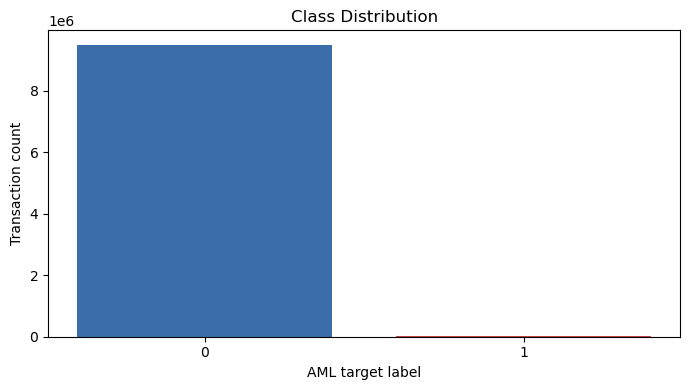

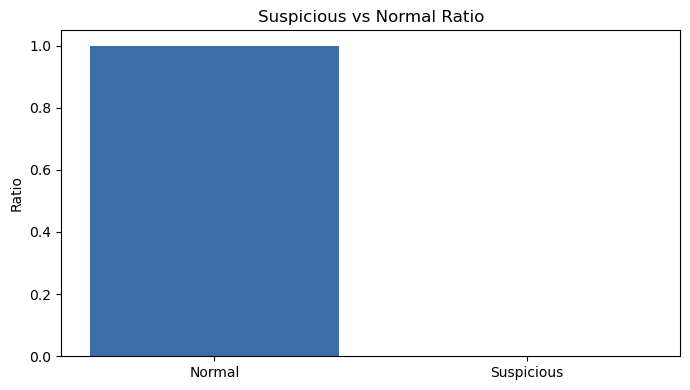

Class distribution figures saved. Interpretation: AML data is usually imbalanced, so accuracy alone can be misleading.


In [51]:
def save_current_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()


if (METRICS_DIR / "class_distribution.csv").exists():
    class_df = pd.read_csv(METRICS_DIR / "class_distribution.csv")
    label_col = class_df.columns[0]
    plt.figure(figsize=(7, 4))
    plt.bar(class_df[label_col].astype(str), class_df["count"], color=["#3b6ea8", "#c74444"][: len(class_df)])
    plt.xlabel("AML target label")
    plt.ylabel("Transaction count")
    plt.title("Class Distribution")
    save_current_figure(FIGURES_DIR / "class_distribution.png")

    total = class_df["count"].sum()
    suspicious_count_plot = 0
    for _, row in class_df.iterrows():
        label_text = str(row[label_col]).strip().lower()
        if label_text in {"1", "true", "yes", "suspicious"}:
            suspicious_count_plot += row["count"]
    if suspicious_count_plot == 0 and len(class_df) > 1:
        suspicious_count_plot = class_df.sort_values("count").iloc[0]["count"]
    suspicious_ratio_plot = suspicious_count_plot / total if total else 0
    plt.figure(figsize=(7, 4))
    plt.bar(["Normal", "Suspicious"], [1 - suspicious_ratio_plot, suspicious_ratio_plot], color=["#3b6ea8", "#c74444"])
    plt.ylabel("Ratio")
    plt.title("Suspicious vs Normal Ratio")
    save_current_figure(FIGURES_DIR / "suspicious_ratio.png")
    print("Class distribution figures saved. Interpretation: AML data is usually imbalanced, so accuracy alone can be misleading.")
else:
    print("Class distribution figure skipped because class_distribution.csv is missing.")

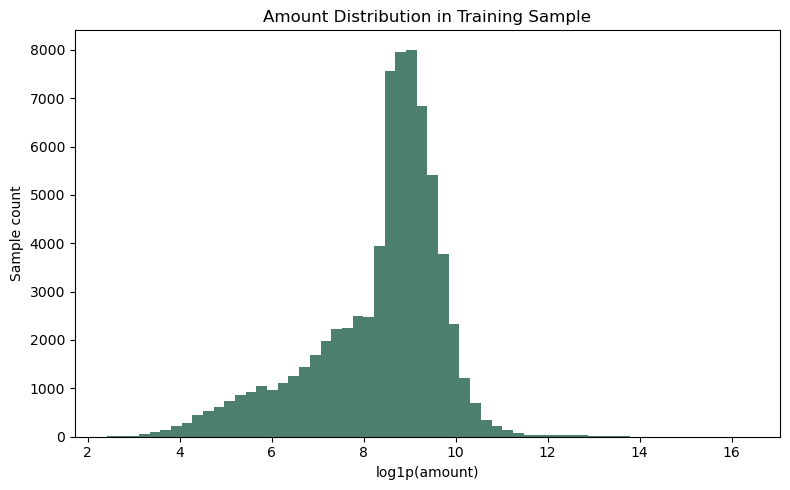

Amount distribution figure saved. Interpretation: log transformation reduces skew in transaction amounts.


In [52]:
if test_path.exists():
    plot_test_df = pd.read_csv(test_path)
    if "amount_log" in plot_test_df.columns:
        plt.figure(figsize=(8, 5))
        plt.hist(plot_test_df["amount_log"].replace([np.inf, -np.inf], np.nan).dropna(), bins=60, color="#4d7f6f")
        plt.xlabel("log1p(amount)")
        plt.ylabel("Sample count")
        plt.title("Amount Distribution in Training Sample")
        save_current_figure(FIGURES_DIR / "amount_distribution_sample.png")
        print("Amount distribution figure saved. Interpretation: log transformation reduces skew in transaction amounts.")
    else:
        print("Amount distribution figure skipped because amount_log is missing in the sample.")
else:
    print("Amount distribution figure skipped because the test split is missing.")

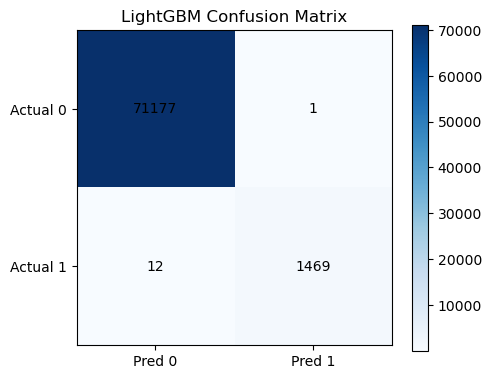

Confusion matrix saved. Interpretation: false negatives are especially important in AML because missed suspicious transactions create compliance risk.


In [53]:
cm_path = METRICS_DIR / "confusion_matrix_lightgbm.csv"
if cm_path.exists():
    cm_df = pd.read_csv(cm_path, index_col=0)
    values = cm_df.values
    plt.figure(figsize=(5, 4))
    plt.imshow(values, cmap="Blues")
    plt.title("LightGBM Confusion Matrix")
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["Actual 0", "Actual 1"])
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            plt.text(j, i, int(values[i, j]), ha="center", va="center", color="black")
    plt.colorbar()
    save_current_figure(FIGURES_DIR / "confusion_matrix_lightgbm.png")
    print("Confusion matrix saved. Interpretation: false negatives are especially important in AML because missed suspicious transactions create compliance risk.")
else:
    print("Confusion matrix skipped because LightGBM evaluation output is missing.")

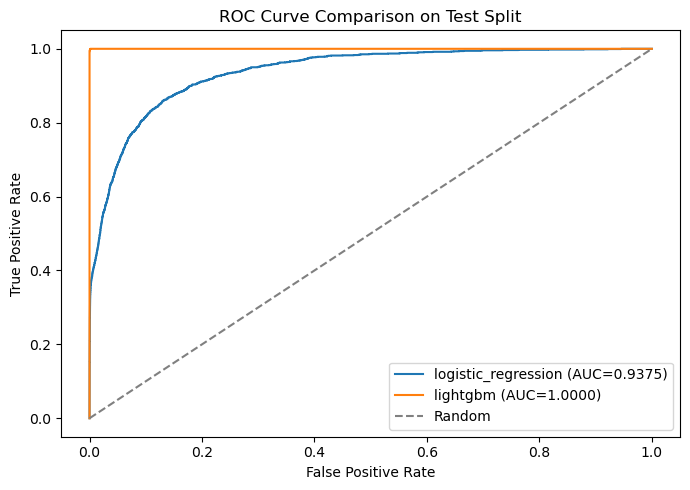

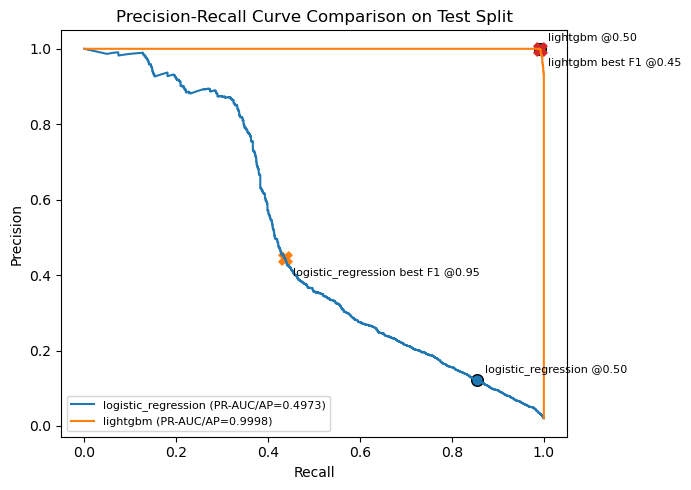

### Precision-Recall Curve Operating Points

,model,point,threshold,precision,recall,f1,average_precision_pr_auc
0,logistic_regression,threshold 0.50 / metric table,0.50,0.121506,0.854153,0.212748,0.497320
1,logistic_regression,best F1 threshold,0.95,0.444597,0.436192,0.440354,0.497320
2,lightgbm,threshold 0.50 / metric table,0.50,0.999320,0.991897,0.995595,0.999766
3,lightgbm,best F1 threshold,0.45,0.999320,0.991897,0.995595,0.999766


The precision and recall values in the model metrics table are single operating points at threshold 0.50. The precision-recall curve shows all possible operating points across thresholds, and PR-AUC/Average Precision summarizes the whole curve. Therefore, the curve and the fixed-threshold table are related but not expected to look identical.

In [54]:
if test_path.exists():
    with open(training_summary_path, "r", encoding="utf-8") as file:
        curve_training_summary = json.load(file)
    curve_features = curve_training_summary["usable_feature_columns"]
    curve_test_df = pd.read_csv(test_path)
    x_test_curve = curve_test_df[curve_features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_test_curve = curve_test_df["label"].astype(int)

    curve_models = {}
    for model_name in ["logistic_regression", "lightgbm"]:
        model_path = MODELS_DIR / f"{model_name}.joblib"
        if model_path.exists():
            curve_models[model_name] = joblib.load(model_path)

    curve_probabilities = {name: predict_probability(model, x_test_curve) for name, model in curve_models.items()}
    threshold_for_markers_df = pd.read_csv(METRICS_DIR / "threshold_tuning.csv") if (METRICS_DIR / "threshold_tuning.csv").exists() else pd.DataFrame()
    operating_rows = []

    if curve_probabilities:
        plt.figure(figsize=(7, 5))
        for model_name, y_prob in curve_probabilities.items():
            fpr, tpr, _ = roc_curve(y_test_curve, y_prob)
            auc_value = roc_auc_score(y_test_curve, y_prob)
            plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.4f})")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve Comparison on Test Split")
        plt.legend()
        save_current_figure(FIGURES_DIR / "roc_curve_models.png")

        plt.figure(figsize=(7, 5))
        for model_name, y_prob in curve_probabilities.items():
            precision_values, recall_values, _ = precision_recall_curve(y_test_curve, y_prob)
            ap_value = average_precision_score(y_test_curve, y_prob)
            plt.plot(recall_values, precision_values, label=f"{model_name} (PR-AUC/AP={ap_value:.4f})")

            # Mark the same fixed 0.50 threshold used in the metrics table.
            fixed_pred = (y_prob >= 0.50).astype(int)
            fixed_precision = precision_score(y_test_curve, fixed_pred, zero_division=0)
            fixed_recall = recall_score(y_test_curve, fixed_pred, zero_division=0)
            fixed_f1 = f1_score(y_test_curve, fixed_pred, zero_division=0)
            plt.scatter(fixed_recall, fixed_precision, s=70, marker="o", edgecolor="black")
            plt.annotate(f"{model_name} @0.50", (fixed_recall, fixed_precision), textcoords="offset points", xytext=(6, 6), fontsize=8)
            operating_rows.append({
                "model": model_name,
                "point": "threshold 0.50 / metric table",
                "threshold": 0.50,
                "precision": fixed_precision,
                "recall": fixed_recall,
                "f1": fixed_f1,
                "average_precision_pr_auc": ap_value,
            })

            # Mark best-F1 threshold from threshold tuning when available.
            if not threshold_for_markers_df.empty:
                model_thresholds = threshold_for_markers_df[threshold_for_markers_df["model"] == model_name]
                if not model_thresholds.empty:
                    best_row = model_thresholds.sort_values(["f1", "recall"], ascending=False).iloc[0]
                    best_threshold = float(best_row["threshold"])
                    best_pred = (y_prob >= best_threshold).astype(int)
                    best_precision = precision_score(y_test_curve, best_pred, zero_division=0)
                    best_recall = recall_score(y_test_curve, best_pred, zero_division=0)
                    best_f1 = f1_score(y_test_curve, best_pred, zero_division=0)
                    plt.scatter(best_recall, best_precision, s=90, marker="X")
                    plt.annotate(f"{model_name} best F1 @{best_threshold:.2f}", (best_recall, best_precision), textcoords="offset points", xytext=(6, -12), fontsize=8)
                    operating_rows.append({
                        "model": model_name,
                        "point": "best F1 threshold",
                        "threshold": best_threshold,
                        "precision": best_precision,
                        "recall": best_recall,
                        "f1": best_f1,
                        "average_precision_pr_auc": ap_value,
                    })

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve Comparison on Test Split")
        plt.legend(fontsize=8)
        save_current_figure(FIGURES_DIR / "precision_recall_curve_models.png")

        operating_points_df = pd.DataFrame(operating_rows)
        display(Markdown("### Precision-Recall Curve Operating Points"))
        display(operating_points_df)
        display(Markdown("The precision and recall values in the model metrics table are single operating points at threshold 0.50. The precision-recall curve shows all possible operating points across thresholds, and PR-AUC/Average Precision summarizes the whole curve. Therefore, the curve and the fixed-threshold table are related but not expected to look identical."))
    else:
        print("ROC and precision-recall figures skipped because saved models are not available.")
else:
    print("ROC and precision-recall figures skipped because the test split is missing.")


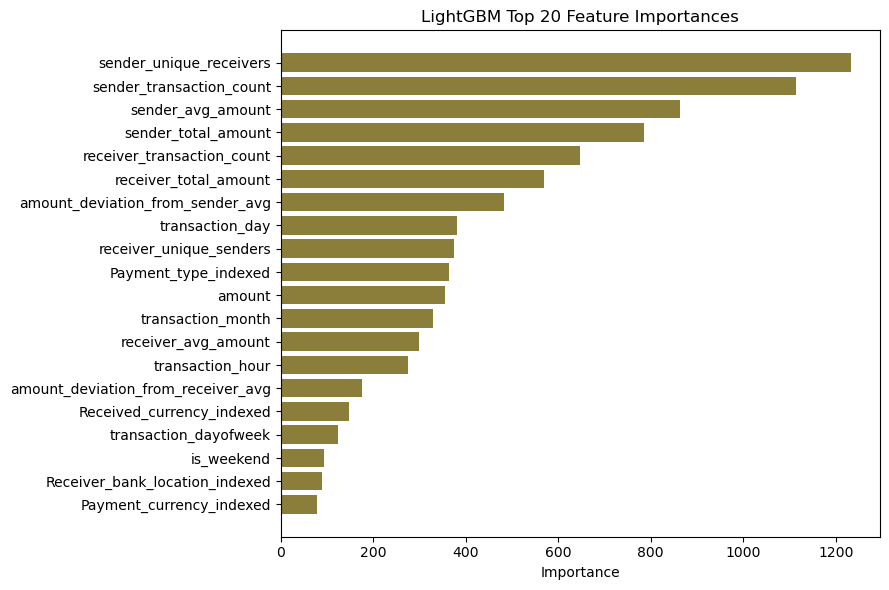

Feature importance figure saved. Interpretation: important graph and amount features indicate repeated account behavior and transaction scale patterns.


In [55]:
lightgbm_model_path = MODELS_DIR / "lightgbm.joblib"
if lightgbm_model_path.exists() and training_summary_path.exists():
    lightgbm_model = joblib.load(lightgbm_model_path)
    with open(training_summary_path, "r", encoding="utf-8") as file:
        training_summary = json.load(file)
    usable_feature_columns = training_summary["usable_feature_columns"]
    if hasattr(lightgbm_model, "feature_importances_"):
        importance_df = pd.DataFrame({"feature": usable_feature_columns, "importance": lightgbm_model.feature_importances_})
        top_importance_df = importance_df.sort_values("importance", ascending=False).head(20).sort_values("importance")
        plt.figure(figsize=(9, 6))
        plt.barh(top_importance_df["feature"], top_importance_df["importance"], color="#8b7d3a")
        plt.xlabel("Importance")
        plt.title("LightGBM Top 20 Feature Importances")
        save_current_figure(FIGURES_DIR / "feature_importance_lightgbm_top20.png")
        print("Feature importance figure saved. Interpretation: important graph and amount features indicate repeated account behavior and transaction scale patterns.")
else:
    print("Feature importance skipped because the LightGBM model or training summary is missing.")

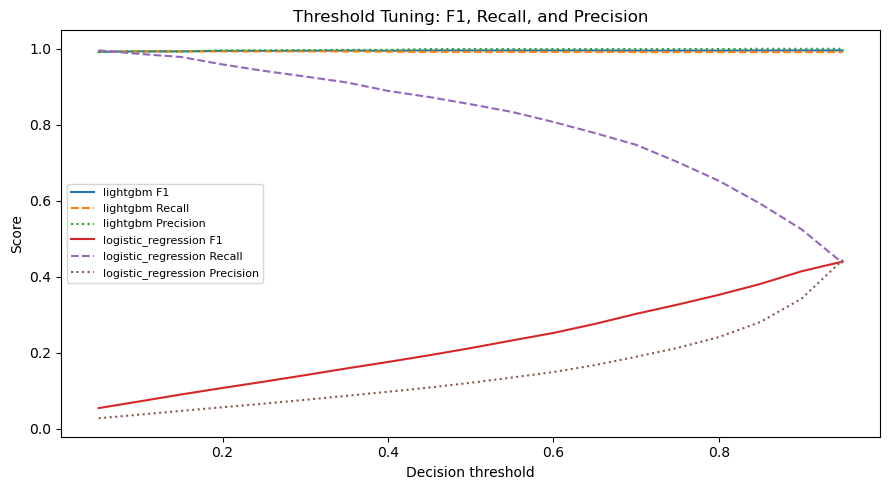

Threshold tuning figure saved. Interpretation: lowering the threshold can increase recall, but may reduce precision.


In [56]:
threshold_path = METRICS_DIR / "threshold_tuning.csv"
if threshold_path.exists():
    threshold_plot_df = pd.read_csv(threshold_path)
    plt.figure(figsize=(9, 5))
    for model_name, group in threshold_plot_df.groupby("model"):
        plt.plot(group["threshold"], group["f1"], label=f"{model_name} F1")
        plt.plot(group["threshold"], group["recall"], linestyle="--", label=f"{model_name} Recall")
        plt.plot(group["threshold"], group["precision"], linestyle=":", label=f"{model_name} Precision")
    plt.xlabel("Decision threshold")
    plt.ylabel("Score")
    plt.title("Threshold Tuning: F1, Recall, and Precision")
    plt.legend(fontsize=8)
    save_current_figure(FIGURES_DIR / "threshold_f1_recall_precision.png")
    print("Threshold tuning figure saved. Interpretation: lowering the threshold can increase recall, but may reduce precision.")
else:
    print("Threshold tuning figure skipped because threshold_tuning.csv is missing.")

### Visualization Dashboard

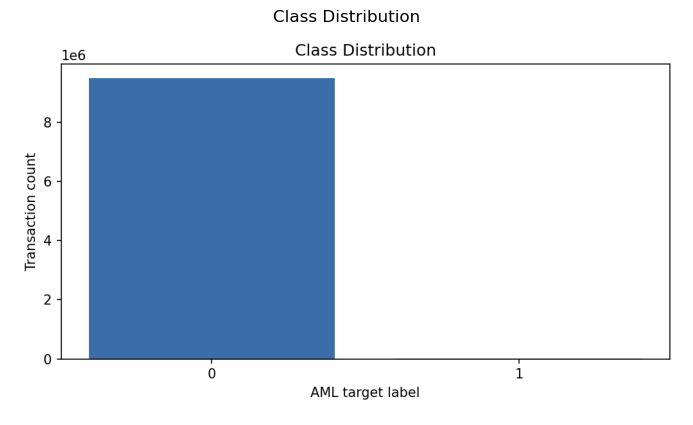

**Interpretation:** The class distribution confirms that suspicious transactions are rare compared with normal transactions.

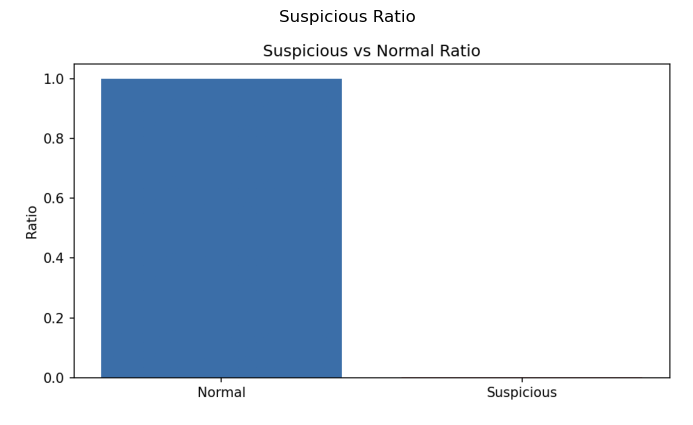

**Interpretation:** The suspicious ratio visualization highlights the severe class imbalance in AML detection.

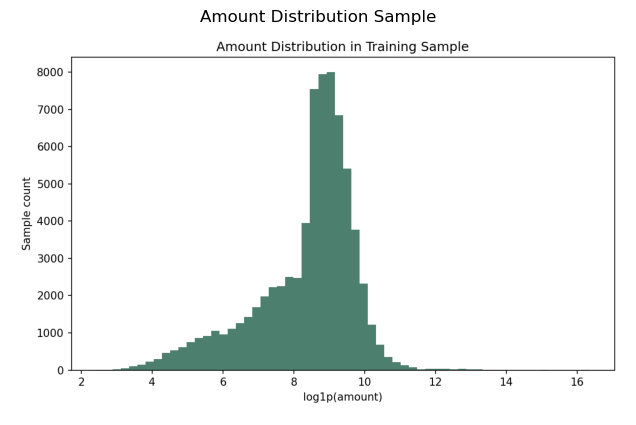

**Interpretation:** The amount distribution from the sample shows why log-transformed amount features are useful.

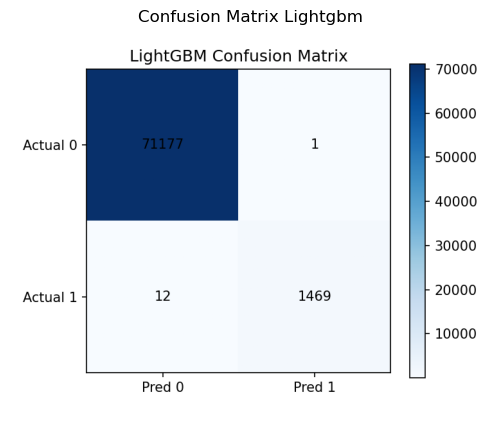

**Interpretation:** The LightGBM confusion matrix shows the balance between detected suspicious cases and false alarms.

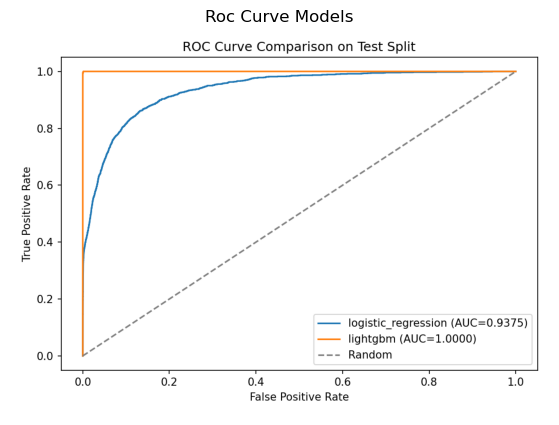

**Interpretation:** The ROC curve compares ranking performance across models, but it should be read with PR-AUC because the data is imbalanced.

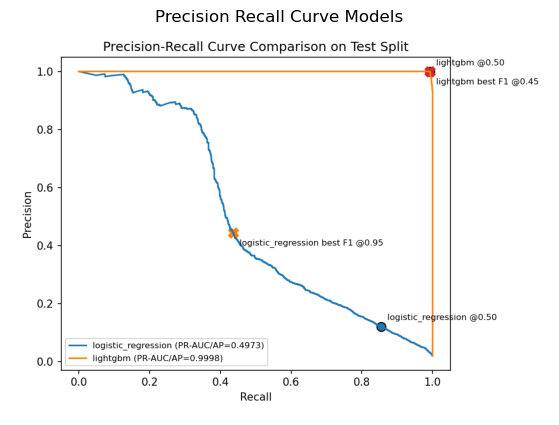

**Interpretation:** The precision-recall curve is especially important for rare suspicious transaction detection.

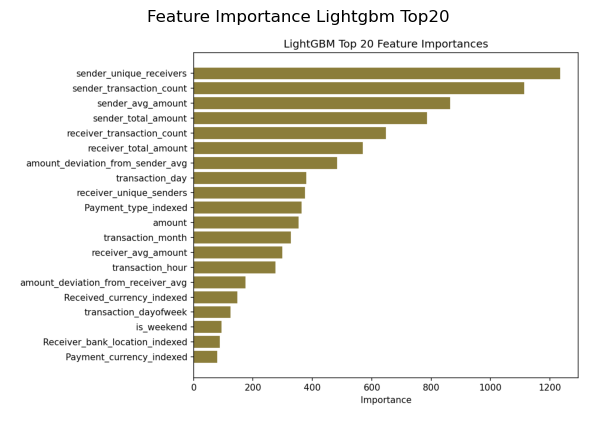

**Interpretation:** The LightGBM feature importance chart identifies the strongest engineered and behavioral predictors.

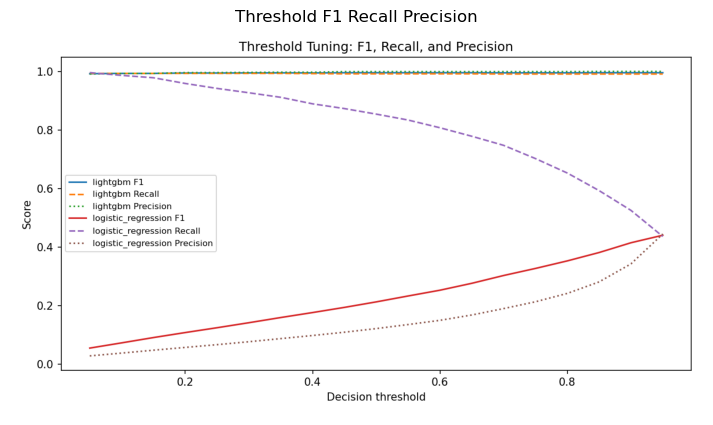

**Interpretation:** The threshold chart shows how precision, recall, and F1-score change as the decision threshold changes.

In [57]:
# INLINE_FIGURE_DASHBOARD_OUTPUT
figure_interpretations = {
    "class_distribution.png": "The class distribution confirms that suspicious transactions are rare compared with normal transactions.",
    "suspicious_ratio.png": "The suspicious ratio visualization highlights the severe class imbalance in AML detection.",
    "amount_distribution_sample.png": "The amount distribution from the sample shows why log-transformed amount features are useful.",
    "confusion_matrix_lightgbm.png": "The LightGBM confusion matrix shows the balance between detected suspicious cases and false alarms.",
    "roc_curve_models.png": "The ROC curve compares ranking performance across models, but it should be read with PR-AUC because the data is imbalanced.",
    "precision_recall_curve_models.png": "The precision-recall curve is especially important for rare suspicious transaction detection.",
    "feature_importance_lightgbm_top20.png": "The LightGBM feature importance chart identifies the strongest engineered and behavioral predictors.",
    "threshold_f1_recall_precision.png": "The threshold chart shows how precision, recall, and F1-score change as the decision threshold changes.",
}

display(Markdown("### Visualization Dashboard"))
for figure_name, interpretation in figure_interpretations.items():
    figure_path = FIGURES_DIR / figure_name
    if figure_path.exists():
        image = plt.imread(figure_path)
        plt.figure(figsize=(9, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(figure_name.replace("_", " ").replace(".png", "").title())
        plt.show()
        display(Markdown(f"**Interpretation:** {interpretation}"))
    else:
        display(Markdown(f"**Figure not available yet:** `{figure_name}`. Run the visualization section to generate it."))

## 15. Final Result Interpretation

After running the notebook, compare `outputs/metrics/model_metrics.csv` to identify the best model. The best model should be selected primarily from PR-AUC, Recall, and F1-score instead of accuracy.

Accuracy is less important for AML detection because suspicious transactions are rare. A model can appear accurate by predicting most transactions as normal. Recall matters because it measures how many suspicious transactions are found. F1-score balances precision and recall. PR-AUC is useful for imbalanced data because it focuses on performance for the suspicious class.

Feature importance should be interpreted from `outputs/figures/feature_importance_lightgbm_top20.png`. Important amount, time, currency, cross-border, and graph aggregation features indicate which transaction behavior patterns are useful for detection.

Knowledge discovered from the dataset should focus on class imbalance, suspicious transaction rarity, transaction amount behavior, typology distribution, and account-level sender-receiver patterns.

Graph-based features help AML detection because suspicious behavior often appears through repeated account interactions, unusual counterparties, and transaction amounts that deviate from an account's normal activity.

Limitations:

- The dataset is synthetic, so real-world AML performance may differ.
- Model training uses a controlled sample for local laptop feasibility.
- Full preprocessing and feature engineering are done using PySpark, but scikit-learn and LightGBM are trained on the sample.

## 16. Export Report-Ready Markdown

In [58]:
def markdown_table_from_dataframe(metrics_df):
    columns = list(metrics_df.columns)
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = []
    for _, row in metrics_df.iterrows():
        values = []
        for column in columns:
            value = row[column]
            if isinstance(value, float):
                values.append(f"{value:.4f}")
            else:
                values.append(str(value))
        rows.append("| " + " | ".join(values) + " |")
    return "\n".join([header, separator, *rows])


def markdown_metrics_table(metrics_path):
    if not metrics_path.exists():
        return "Model metrics are not available yet. Run the training and evaluation sections first."
    metrics_df = pd.read_csv(metrics_path)
    return markdown_table_from_dataframe(metrics_df)


metrics_table = markdown_metrics_table(METRICS_DIR / "model_metrics.csv")
figure_names = [
    "class_distribution.png",
    "suspicious_ratio.png",
    "amount_distribution_sample.png",
    "confusion_matrix_lightgbm.png",
    "roc_curve_models.png",
    "precision_recall_curve_models.png",
    "feature_importance_lightgbm_top20.png",
    "threshold_f1_recall_precision.png",
]
figure_list = "\n".join(f"- `outputs/figures/{name}`" for name in figure_names)

methodology_md = f"""
# Methodology

## Dataset

This project uses the SAML-D Anti Money Laundering Transaction Data from Kaggle dataset `berkanoztas/synthetic-transaction-monitoring-dataset-aml`. The target column is `Is_laundering`, normalized into a binary `label`.

## Big Data Tool

PySpark is used for loading, EDA aggregation, preprocessing, feature engineering, graph-based aggregation, and Parquet output. The full dataset is never converted to Pandas.

## Preprocessing

The workflow normalizes the target, casts amount to double, creates `amount_log`, fills categorical nulls with `unknown`, fills numeric nulls with zero, and drops exact duplicates when feasible.

## Feature Engineering

The notebook creates time features, amount features, currency mismatch, cross-border indicators, categorical indexes, and Spark groupBy sender-receiver graph features.

## Model Training

The full Spark dataset is sampled for local training. Logistic Regression is used as a baseline with class balancing, and LightGBM is used as the main model with `scale_pos_weight`.

## Evaluation

Models are evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, confusion matrix, classification report, and threshold tuning.
"""

results_template_md = f"""
# Results Template

## Model Metrics

{metrics_table}

## Visualizations

{figure_list}

## Interpretation

Discuss which model performs best, why recall and PR-AUC matter for rare suspicious transactions, and how graph-based features help detect abnormal sender-receiver behavior.
"""

final_project_summary_md = f"""
# Final Project Summary

## Project

Big Data Anti-Money Laundering Detection Using Graph-Based Feature Engineering, Imbalanced Learning, and Explainable Machine Learning.

## Dataset

SAML-D Anti Money Laundering Transaction Data from Kaggle dataset `berkanoztas/synthetic-transaction-monitoring-dataset-aml`.

## Big Data Processing

PySpark processes the full dataset through loading, EDA, preprocessing, feature engineering, graph aggregation, and sampling. Only aggregated outputs and the controlled training sample are converted to Pandas.

## Model Training and Evaluation

The notebook trains Logistic Regression and LightGBM models. Evaluation focuses on Recall, F1-score, and PR-AUC because suspicious AML transactions are rare.

## Visualizations

{figure_list}

## Conclusion

The project provides an end-to-end, report-ready AML detection workflow. Graph-based features represent sender and receiver behavior, while imbalanced learning and threshold tuning help adapt the model to suspicious-transaction detection.
"""

(REPORTS_DIR / "methodology.md").write_text(methodology_md.strip() + "\n", encoding="utf-8")
(REPORTS_DIR / "results_template.md").write_text(results_template_md.strip() + "\n", encoding="utf-8")
(REPORTS_DIR / "final_project_summary.md").write_text(final_project_summary_md.strip() + "\n", encoding="utf-8")

print("Report-ready markdown files exported:")
print("- outputs/reports/final_project_summary.md")
print("- outputs/reports/methodology.md")
print("- outputs/reports/results_template.md")

Report-ready markdown files exported:
- outputs/reports/final_project_summary.md
- outputs/reports/methodology.md
- outputs/reports/results_template.md


## Result Interpretation

This section displays the report-ready interpretation inside the notebook, using the saved metrics and figures when available.

In [59]:
# INLINE_FINAL_REPORT_MARKDOWN_OUTPUT
metrics_path = METRICS_DIR / "model_metrics.csv"
feature_importance_note = "LightGBM feature importance is available in `outputs/figures/feature_importance_lightgbm_top20.png` after visualization runs."
if metrics_path.exists():
    final_metrics_df = pd.read_csv(metrics_path)
    best_row = final_metrics_df.rename(columns={"average_precision": "pr_auc"}).sort_values(["pr_auc", "recall", "f1"], ascending=False).iloc[0]
    best_model_name = best_row["model"]
    best_model_sentence = f"The best model is **{best_model_name}**, selected using PR-AUC, Recall, and F1-score."
else:
    best_model_name = "not available yet"
    best_model_sentence = "The best model will be selected after model evaluation is run."

final_summary_text = f"""
# Final Project Summary

## Result Interpretation

The dataset is highly imbalanced: suspicious AML transactions are much rarer than normal transactions. This means accuracy alone is not sufficient, because a model can obtain high accuracy while missing suspicious activity.

EDA shows important transaction patterns in class imbalance, payment types, amount distribution, currency mismatch, and cross-border activity. The graph-based feature engineering step adds sender and receiver behavior features such as transaction counts, total amount, average amount, unique counterparties, and amount deviation from account averages.

{best_model_sentence}

PR-AUC, Recall, and F1-score are prioritized because AML detection focuses on identifying rare suspicious transactions while controlling false alarms. Graph-based features help because laundering behavior often appears through repeated sender-receiver interactions and unusual account-level transaction patterns. However, the very high LightGBM score must be interpreted carefully because the graph features are highly predictive and were computed before the random train/test split; a stricter future evaluation should use time-based/account-based splitting or compute graph statistics from training data only.

## Limitations

The dataset is synthetic, so real-world validation is future work. Model training uses a controlled local sample for laptop feasibility, while full preprocessing and feature engineering are performed with PySpark.

## Final Conclusion

The project successfully used PySpark for Big Data preprocessing. It created graph-based features from sender-receiver transaction behavior, trained Logistic Regression and LightGBM models, and selected the best model based on Recall, F1-score, and PR-AUC. Suspicious AML detection is strongly affected by class imbalance. The very high LightGBM result should be treated as optimistic because graph statistics were computed before random splitting; future work should validate the approach with time-based/account-based splitting and graph features computed from training data only.
"""

display(Markdown(final_summary_text))
(REPORTS_DIR / "final_project_summary.md").write_text(final_summary_text.strip() + "\n", encoding="utf-8")


# Final Project Summary

## Result Interpretation

The dataset is highly imbalanced: suspicious AML transactions are much rarer than normal transactions. This means accuracy alone is not sufficient, because a model can obtain high accuracy while missing suspicious activity.

EDA shows important transaction patterns in class imbalance, payment types, amount distribution, currency mismatch, and cross-border activity. The graph-based feature engineering step adds sender and receiver behavior features such as transaction counts, total amount, average amount, unique counterparties, and amount deviation from account averages.

The best model is **lightgbm**, selected using PR-AUC, Recall, and F1-score.

PR-AUC, Recall, and F1-score are prioritized because AML detection focuses on identifying rare suspicious transactions while controlling false alarms. Graph-based features help because laundering behavior often appears through repeated sender-receiver interactions and unusual account-level transaction patterns. However, the very high LightGBM score must be interpreted carefully because the graph features are highly predictive and were computed before the random train/test split; a stricter future evaluation should use time-based/account-based splitting or compute graph statistics from training data only.

## Limitations

The dataset is synthetic, so real-world validation is future work. Model training uses a controlled local sample for laptop feasibility, while full preprocessing and feature engineering are performed with PySpark.

## Final Conclusion

The project successfully used PySpark for Big Data preprocessing. It created graph-based features from sender-receiver transaction behavior, trained Logistic Regression and LightGBM models, and selected the best model based on Recall, F1-score, and PR-AUC. Suspicious AML detection is strongly affected by class imbalance, and future work should validate the approach on real production data.


1965